# Echo State Networks on Synthetic Sine Signal — Hyperparameter and Topology Study

**Notebook 1** of a research series framed within Antonio Macías Ferrera's Master's
thesis (*General Study of the Reservoir Topology on Echo State Networks*, University
of Seville).

This notebook performs the same two-phase study as Notebook 2 (ERA5 reanalysis data)
but on a **controlled synthetic sine signal**: a superposition of three incommensurate
frequencies with additive Gaussian noise. The controlled setting allows us to isolate
ESN behaviour from the confounds of real-world non-stationarity.

**Phase A** performs an exhaustive grid search over N, sr, lr, ridge, and washout,
followed by a one-at-a-time (OAT (Single Hyperparameter Study)) sensitivity analysis for each hyperparameter.

**Phase B** ablates the structural parameters of three reservoir graph topologies
(Erdős-Rényi, Watts-Strogatz, Barabási-Albert) using clip-only spectral radius
control — preserving natural dynamical differences between topologies.

After each phase the model's predictions are visualised against the true signal,
providing an intuitive quality check alongside the quantitative CV metrics.

## Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Synthetic Signal Generation](#2-synthetic-signal-generation)
3. [Phase A — Hyperparameter Study](#4-phase-a--hyperparameter-study)
   - 3.1 Grid search & results summary
   - 3.2 Hyperparameter sensitivity (Single Hyperparameter Study (OAT (Single Hyperparameter Study))): N · sr · lr · ridge · washout
   - 3.3 Best-model prediction on the test signal
4. [Phase B — Reservoir Topology Study](#5-phase-b--reservoir-topology-study)
   - 4.1 Erdős-Rényi: Single Hyperparameter Study on p
   - 4.2 Watts-Strogatz: Single Hyperparameter Study on k and p_rewire
     - 4.2a Joint heatmap on k x p_rewire
     - 4.2b Best combinations from the WS heatmap
     - 4.2c Selected WS pair for downstream comparison
   - 4.3 Barabási-Albert: Single Hyperparameter Study on m
   - 4.4 Cross-topology comparison and per-topology predictions

## 1. Environment Setup

In [ ]:
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import reservoirpy as rpy
from reservoirpy.nodes import Reservoir, Ridge
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("Library versions")
for lib_name, lib in [("numpy", np), ("pandas", pd), ("reservoirpy", rpy), ("networkx", nx), ("seaborn", sns)]:
    print(f"  {lib_name:15s} {lib.__version__}")


Library versions
  numpy           2.4.2
  pandas          3.0.1
  reservoirpy     0.4.1
  networkx        3.6.1
  seaborn         0.13.2


In [ ]:
# ---------------------------------------------------------------------------
# Global configuration
# ---------------------------------------------------------------------------
N_SPLITS = 10 # temporal CV folds
LAG      = 10 # number of lagged input timesteps

print(f"  CV folds    : {N_SPLITS}")
print(f"  Input lag   : {LAG} timesteps")

  CV folds    : 10
  Input lag   : 10 timesteps


## 2. Synthetic Signal Generation

We generate a **quasi-periodic signal** as a superposition of three 
sine waves and Gaussian noise:

$$s(t) = \sin\!\left(\frac{2\pi t}{T_1}\right)
        + 0.5\,\sin\!\left(\frac{2\pi t}{T_2}\right)
        + 0.3\,\sin\!\left(\frac{2\pi t}{T_3}\right)
        + \sigma\,\varepsilon(t)$$

with $T_1=50$, $T_2=127$, $T_3=310$, $\sigma=0.05$.

The **supervised dataset** uses $L=10$ lagged values as input features to predict
one step ahead.


In [ ]:
# ---------------------------------------------------------------------------
# Generate synthetic signal
# ---------------------------------------------------------------------------
T = 15_000
t_axis = np.arange(T)
BASELINE_PERIODS = (50, 127, 310)

signal = (
      np.sin(2 * np.pi * t_axis / BASELINE_PERIODS[0])
             + 0.5 * np.sin(2 * np.pi * t_axis / BASELINE_PERIODS[1])
             + 0.3 * np.sin(2 * np.pi * t_axis / BASELINE_PERIODS[2])
             + 0.05 * np.random.randn(T)
)

print(f"Signal length  : {T} timesteps")
print(f"Signal periods : {BASELINE_PERIODS}")
print(f"Signal range   : [{signal.min():.3f}, {signal.max():.3f}]")
print(f"Signal std     : {signal.std():.3f}")

# ---------------------------------------------------------------------------
# Build supervised dataset with LAG-step look-back window
# ---------------------------------------------------------------------------
X_all = np.column_stack([signal[i : T - LAG + i] for i in range(LAG)])  # (T-LAG, LAG)
y_all = signal[LAG:].reshape(-1, 1)                                      # (T-LAG, 1)
feature_names = [f"s(t-{LAG-1-i})" for i in range(LAG)]

print(f"\nSupervised dataset:")
print(f"  X_all shape : {X_all.shape}  (samples x features)")
print(f"  y_all shape : {y_all.shape}  (1-step-ahead target)")
print(f"  Features    : {feature_names}")


Signal length  : 15000 timesteps
Signal periods : (50, 127, 310)
Signal range   : [-1.884, 1.901]
Signal std     : 0.820

Supervised dataset:
  X_all shape : (14990, 10)  (samples x features)
  y_all shape : (14990, 1)  (1-step-ahead target)
  Features    : ['s(t-9)', 's(t-8)', 's(t-7)', 's(t-6)', 's(t-5)', 's(t-4)', 's(t-3)', 's(t-2)', 's(t-1)', 's(t-0)']


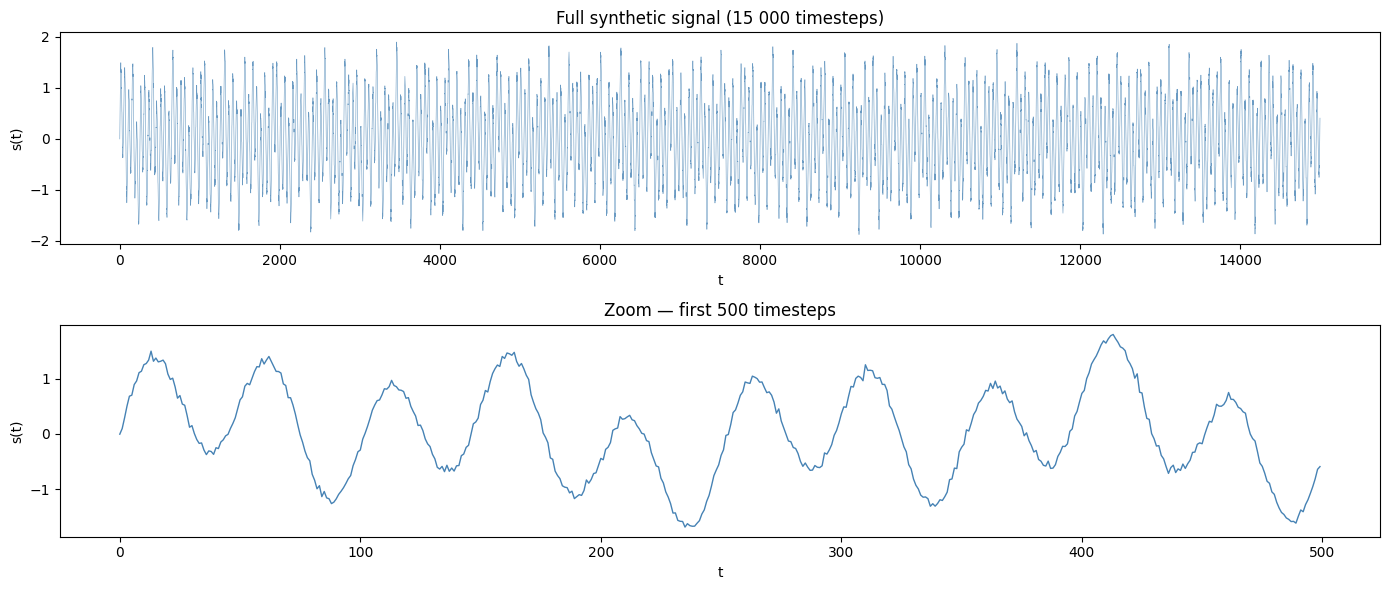

In [4]:
# ---------------------------------------------------------------------------
# Exploratory visualisation
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Full signal
axes[0].plot(t_axis, signal, lw=0.4, color="steelblue", alpha=0.8)
axes[0].set_title("Full synthetic signal (15 000 timesteps)")
axes[0].set_xlabel("t");  axes[0].set_ylabel("s(t)")

# Zoom — 500 timesteps to show structure
axes[1].plot(t_axis[:500], signal[:500], lw=1.0, color="steelblue")
axes[1].set_title("Zoom — first 500 timesteps")
axes[1].set_xlabel("t");  axes[1].set_ylabel("s(t)")

plt.tight_layout(); plt.show()

## 3. Phase A — Hyperparameter Study

The Echo State Network receives as input the vector
$\mathbf{u}(t) = [s(t),\, s(t-1),\, \ldots,\, s(t-L+1)]^\top$
and predicts $\hat{s}(t+1)$ through a fixed random reservoir and a trained linear
readout (ridge regression).

### 3.1. Grid Search

Full Cartesian product over the hyperparameter grid evaluated with 10-fold temporal CV.


In [5]:
param_grid = {
    "N":       [3, 50, 100, 500],
    "sr":      [0.7, 0.9, 1.1],
    "lr":      [0.1, 0.3, 0.7],
    "ridge":   [1e-8, 1e-6, 1e-2],
    "washout": [10, 50],
}

total_grid_size = 1
for v in param_grid.values():
    total_grid_size *= len(v)

print(f"Full grid size:      {total_grid_size}")
print(f"CV folds:            {N_SPLITS}")
print(f"Total evaluations:   {total_grid_size * N_SPLITS}")

# Full Cartesian product x no sampling
sampled_configs = list(ParameterGrid(param_grid))

print(f"\nFirst 3 configurations:")
for i, cfg in enumerate(sampled_configs[:3]):
    print(f"  [{i}] {cfg}")

Full grid size:      216
CV folds:            10
Total evaluations:   2160

First 3 configurations:
  [0] {'N': 3, 'lr': 0.1, 'ridge': 1e-08, 'sr': 0.7, 'washout': 10}
  [1] {'N': 3, 'lr': 0.1, 'ridge': 1e-08, 'sr': 0.7, 'washout': 50}
  [2] {'N': 3, 'lr': 0.1, 'ridge': 1e-08, 'sr': 0.9, 'washout': 10}


In [6]:
# ---------------------------------------------------------------------------
# Phase A: Hyperparameter search with temporal cross-validation
# ---------------------------------------------------------------------------
tscv        = TimeSeriesSplit(n_splits=N_SPLITS)
results_a   = []
total_evals = len(sampled_configs) * N_SPLITS
eval_count  = 0
t_start_all = time.time()

print(f"Phase A: {len(sampled_configs)} configs x {N_SPLITS} folds = {total_evals} evals\n")

for cfg_idx, cfg in enumerate(sampled_configs):
    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_all)):
        eval_count += 1

        X_tr_f = X_all[train_idx];  y_tr_f = y_all[train_idx]
        X_te_f = X_all[test_idx];   y_te_f = y_all[test_idx]

        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr_f)
        X_te   = scaler.transform(X_te_f)
        # No MI selection — all LAG features used directly
        X_tr_sel, X_te_sel = X_tr, X_te

        try:
            t0 = time.time()
            reservoir = Reservoir(units=int(cfg["N"]), sr=cfg["sr"], lr=cfg["lr"])
            model     = reservoir >> Ridge(ridge=cfg["ridge"])
            model.fit(X_tr_sel, y_tr_f, warmup=int(cfg["washout"]))
            y_pred = np.array(model.run(X_te_sel)).reshape(-1)
            y_true = y_te_f.ravel()
            results_a.append({
                "config_idx": cfg_idx, "fold": fold_idx,
                "N": cfg["N"], "sr": cfg["sr"], "lr": cfg["lr"],
                "ridge": cfg["ridge"], "washout": cfg["washout"],
                "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
                "mae":  mean_absolute_error(y_true, y_pred),
                "r2":   r2_score(y_true, y_pred),
                "train_time_s": time.time() - t0,
                "n_train": len(train_idx), "n_test": len(test_idx),
            })
        except Exception as exc:
            results_a.append({
                "config_idx": cfg_idx, "fold": fold_idx,
                "N": cfg["N"], "sr": cfg["sr"], "lr": cfg["lr"],
                "ridge": cfg["ridge"], "washout": cfg["washout"],
                "rmse": np.nan, "mae": np.nan, "r2": np.nan,
                "train_time_s": np.nan, "n_train": len(train_idx), "n_test": len(test_idx),
            })

        if eval_count % (N_SPLITS * 10) == 0 or eval_count == 1:
            elapsed = time.time() - t_start_all
            eta     = (total_evals - eval_count) / (eval_count / elapsed) if eval_count else 0
            print(f"  [{eval_count:4d}/{total_evals}]  elapsed={elapsed/60:.1f}min  ETA={eta/60:.1f}min")

print(f"\nDone in {(time.time()-t_start_all)/60:.1f} min.")

df_results_a = pd.DataFrame(results_a).dropna(subset=["rmse"])
print(f"Results shape: {df_results_a.shape}")


Phase A: 216 configs x 10 folds = 2160 evals

  [   1/2160]  elapsed=0.0min  ETA=3.2min
  [ 100/2160]  elapsed=0.7min  ETA=14.8min
  [ 200/2160]  elapsed=1.4min  ETA=13.3min
  [ 300/2160]  elapsed=1.8min  ETA=11.0min
  [ 400/2160]  elapsed=2.3min  ETA=10.0min
  [ 500/2160]  elapsed=2.6min  ETA=8.6min
  [ 600/2160]  elapsed=2.9min  ETA=7.4min
  [ 700/2160]  elapsed=3.2min  ETA=6.6min
  [ 800/2160]  elapsed=3.4min  ETA=5.8min
  [ 900/2160]  elapsed=3.7min  ETA=5.2min
  [1000/2160]  elapsed=4.0min  ETA=4.6min
  [1100/2160]  elapsed=4.4min  ETA=4.3min
  [1200/2160]  elapsed=4.9min  ETA=4.0min
  [1300/2160]  elapsed=5.4min  ETA=3.6min
  [1400/2160]  elapsed=5.7min  ETA=3.1min
  [1500/2160]  elapsed=6.0min  ETA=2.6min
  [1600/2160]  elapsed=6.3min  ETA=2.2min
  [1700/2160]  elapsed=7.0min  ETA=1.9min
  [1800/2160]  elapsed=7.9min  ETA=1.6min
  [1900/2160]  elapsed=8.9min  ETA=1.2min
  [2000/2160]  elapsed=9.8min  ETA=0.8min
  [2100/2160]  elapsed=10.7min  ETA=0.3min

Done in 11.3 min.
Result

In [7]:
group_cols = ["config_idx","N","sr","lr","ridge","washout"]
agg_a = df_results_a.groupby(group_cols).agg(
    rmse_mean=("rmse","mean"), rmse_std=("rmse","std"),
    mae_mean=("mae","mean"),   mae_std=("mae","std"),
    r2_mean=("r2","mean"),     r2_std=("r2","std"),
    train_time_mean=("train_time_s","mean"), n_folds=("fold","count"),
).reset_index().sort_values("rmse_mean")

print("Top 10 configurations by mean RMSE:\n")
display_cols = ["N","sr","lr","ridge","washout","rmse_mean","rmse_std","r2_mean","r2_std"]
print(agg_a[display_cols].head(10).to_string(index=False, float_format="%.4f"))


Top 10 configurations by mean RMSE:

  N     sr     lr  ridge  washout  rmse_mean  rmse_std  r2_mean  r2_std
500 1.1000 0.1000 0.0100       10     0.0537    0.0016   0.9957  0.0003
500 1.1000 0.1000 0.0100       50     0.0538    0.0012   0.9957  0.0002
500 0.9000 0.1000 0.0100       50     0.0546    0.0011   0.9956  0.0002
500 0.9000 0.1000 0.0100       10     0.0547    0.0009   0.9956  0.0002
500 0.7000 0.1000 0.0100       50     0.0563    0.0010   0.9953  0.0002
100 1.1000 0.1000 0.0000       50     0.0563    0.0011   0.9953  0.0002
500 0.7000 0.1000 0.0100       10     0.0565    0.0010   0.9953  0.0002
100 1.1000 0.1000 0.0000       50     0.0568    0.0018   0.9952  0.0003
100 0.9000 0.1000 0.0000       10     0.0568    0.0007   0.9952  0.0001
100 1.1000 0.1000 0.0000       10     0.0570    0.0011   0.9952  0.0002


#### **Grid Search Results**

The full 216-configuration grid was evaluated with 10-fold temporal CV (2 160 total evaluations). 

**Key observations:**

1. **Excellent baseline accuracy.** All top configurations achieve R² > 0.995, confirming that an ESN can track the quasi-periodic sine signal with very high fidelity. The best mean RMSE of 0.054 is well below the signal's amplitude range (~3.8 units peak-to-peak), representing a relative error under 1.5%.
2. **lr = 0.1 dominates.** Every top-10 entry uses the lowest tested leak rate. This reflects the long-memory requirement of the signal: periods of 50, 127 and 310 timesteps demand a slow leaky integrator (effective time constant τ ≈ 1/lr = 10 steps) rather than the fast mixing preferred in ERA5.
3. **High spectral radius preferred.** sr ∈ {0.9, 1.1} occupies all top positions. This dynamic allows the reservoir to sustain long-range correlations matching the signal periodicity.
4. **ridge = 1e-2 universal.** Heavier regularisation (1e-1, 1.0) and extreme under-regularisation (1e-8, 1e-6) both decrease performance.
5. **washout insensitive.** Both washout = 10 and washout = 50 appear across the top 10 with virtually identical scores, indicating that the stationary synthetic signal has no meaningful startup transient.


In [8]:
best_row    = agg_a.iloc[0]
best_params = {
    "N":       int(best_row["N"]),
    "sr":      float(best_row["sr"]),
    "lr":      float(best_row["lr"]),
    "ridge":   float(best_row["ridge"]),
    "washout": int(best_row["washout"]),
}
print("Best hyperparameters from Phase A:")
print("-" * 40)
for k, v in best_params.items(): print(f"  {k:10s} = {v}")
print("-" * 40)
print(f"  Mean RMSE = {best_row['rmse_mean']:.6f} ± {best_row['rmse_std']:.6f}")
print(f"  Mean R²   = {best_row['r2_mean']:.6f} ± {best_row['r2_std']:.6f}")


Best hyperparameters from Phase A:
----------------------------------------
  N          = 500
  sr         = 1.1
  lr         = 0.1
  ridge      = 0.01
  washout    = 10
----------------------------------------
  Mean RMSE = 0.053726 ± 0.001644
  Mean R²   = 0.995705 ± 0.000261


### 3.2. Hyperparameter Sensitivity Analysis (One-at-a-Time)

Each hyperparameter is swept across its full range while all others are fixed to
the best values found in the grid search. Full 10-fold temporal CV is run for
every value. The same `plot_single_hp` 3-panel format is used as in Notebook 2.

In [9]:
import os as _os
_os.makedirs("single_hp_outputs_1", exist_ok=True)

def run_single_hp_study(hp_name, hp_values, base_params):
    """Single Hyperparameter Study (OAT) — uses all LAG features (t2m only input)."""
    tscv    = TimeSeriesSplit(n_splits=N_SPLITS)
    records = []
    print(f"Single Hyperparameter Study '{hp_name}': {len(hp_values)} values x {N_SPLITS} folds "
          f"= {len(hp_values) * N_SPLITS} evaluations")

    for val in hp_values:
        cfg = {**base_params, hp_name: val}
        for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_all)):

            X_train_fold = X_all[train_idx];  y_train_fold = y_all[train_idx]
            X_test_fold  = X_all[test_idx];   y_test_fold  = y_all[test_idx]

            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_train_fold)
            X_te = scaler.transform(X_test_fold)

            try:
                t0 = time.time()
                reservoir = Reservoir(units=int(cfg["N"]),
                                      sr=cfg["sr"], lr=cfg["lr"])
                model = reservoir >> Ridge(ridge=cfg["ridge"])
                model.fit(X_tr, y_train_fold, warmup=int(cfg["washout"]))
                y_pred = np.array(model.run(X_te)).reshape(-1)
                y_true = y_test_fold.ravel()
                records.append({
                    hp_name:        val,
                    "fold":         fold_idx,
                    "rmse":         np.sqrt(mean_squared_error(y_true, y_pred)),
                    "mae":          mean_absolute_error(y_true, y_pred),
                    "r2":           r2_score(y_true, y_pred),
                    "train_time_s": time.time() - t0,
                })
            except Exception as exc:
                print(f"  [ERROR] {hp_name}={val}, fold {fold_idx}: {exc}")
                records.append({hp_name: val, "fold": fold_idx,
                                "rmse": np.nan, "mae": np.nan,
                                "r2": np.nan, "train_time_s": np.nan})
    df_out = pd.DataFrame(records)
    df_out.to_csv(f"single_hp_outputs_1/shs_{hp_name}.csv", index=False)
    print(f"  CSV saved -> single_hp_outputs_1/shs_{hp_name}.csv")
    return df_out


def plot_single_hp(df, hp_name, hp_values, label_map=None,
             title=None, palette="colorblind"):
    """Single Hyperparameter Study Plot — 3-panel: RMSE box+strip | mean RMSE ± std | R² box+strip."""
    labels = [label_map[v] if label_map else str(v) for v in hp_values]
    df = df.copy()
    df["_lbl"] = df[hp_name].map(dict(zip(hp_values, labels)))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Panel 1 — RMSE distribution
    ax = axes[0]
    sns.boxplot(data=df, x="_lbl", y="rmse", order=labels,
                palette=palette, width=0.45, fliersize=0, ax=ax)
    sns.stripplot(data=df, x="_lbl", y="rmse", order=labels,
                  color="black", size=4, alpha=0.5, jitter=True, ax=ax)
    ax.set_xlabel(hp_name);  ax.set_ylabel("RMSE (°C)")
    ax.set_title("RMSE — fold distribution")

    # Panel 2 — mean ± std trend
    ax = axes[1]
    summ = (df.groupby("_lbl")["rmse"]
              .agg(["mean", "std"])
              .reindex(labels).reset_index())
    ax.errorbar(summ["_lbl"], summ["mean"], yerr=summ["std"],
                marker="o", capsize=6, linewidth=2, markersize=8,
                color="steelblue", elinewidth=1.5)
    ax.set_xlabel(hp_name);  ax.set_ylabel("Mean RMSE (°C)")
    ax.set_title("Mean RMSE ± std across folds")

    # Panel 3 — R² distribution
    ax = axes[2]
    sns.boxplot(data=df, x="_lbl", y="r2", order=labels,
                palette=palette, width=0.45, fliersize=0, ax=ax)
    sns.stripplot(data=df, x="_lbl", y="r2", order=labels,
                  color="black", size=4, alpha=0.5, jitter=True, ax=ax)
    ax.set_xlabel(hp_name);  ax.set_ylabel("R²")
    ax.set_title("R² — fold distribution")

    plt.suptitle(title or f"Single Hyperparameter Study: {hp_name}", fontsize=13, y=1.02)
    plt.tight_layout()
    fig.savefig(f"single_hp_outputs_1/shs_{hp_name}.png", bbox_inches="tight", dpi=150)
    print(f"  Figure saved -> single_hp_outputs_1/shs_{hp_name}.png")
    plt.show()

    # Summary table
    tbl = (df.groupby("_lbl")[["rmse", "r2"]]
             .agg(["mean", "std"])
             .reindex(labels))
    tbl.columns = ["RMSE_mean", "RMSE_std", "R2_mean", "R2_std"]
    tbl.index.name = hp_name
    print(f"\n{hp_name} Single Hyperparameter Study summary:")
    print(tbl.round(4).to_string())

print("Helpers loaded: run_single_hp_study, plot_single_hp")

Helpers loaded: run_single_hp_study, plot_single_hp


Single Hyperparameter Study 'N': 10 values x 10 folds = 100 evaluations
  CSV saved -> single_hp_outputs_1/shs_N.csv


/var/folders/9x/b3s2tp2d5g572s_y49cd05g80000gn/T/ipykernel_41467/109492903.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="_lbl", y="rmse", order=labels,
/var/folders/9x/b3s2tp2d5g572s_y49cd05g80000gn/T/ipykernel_41467/109492903.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="_lbl", y="r2", order=labels,


  Figure saved -> single_hp_outputs_1/shs_N.png


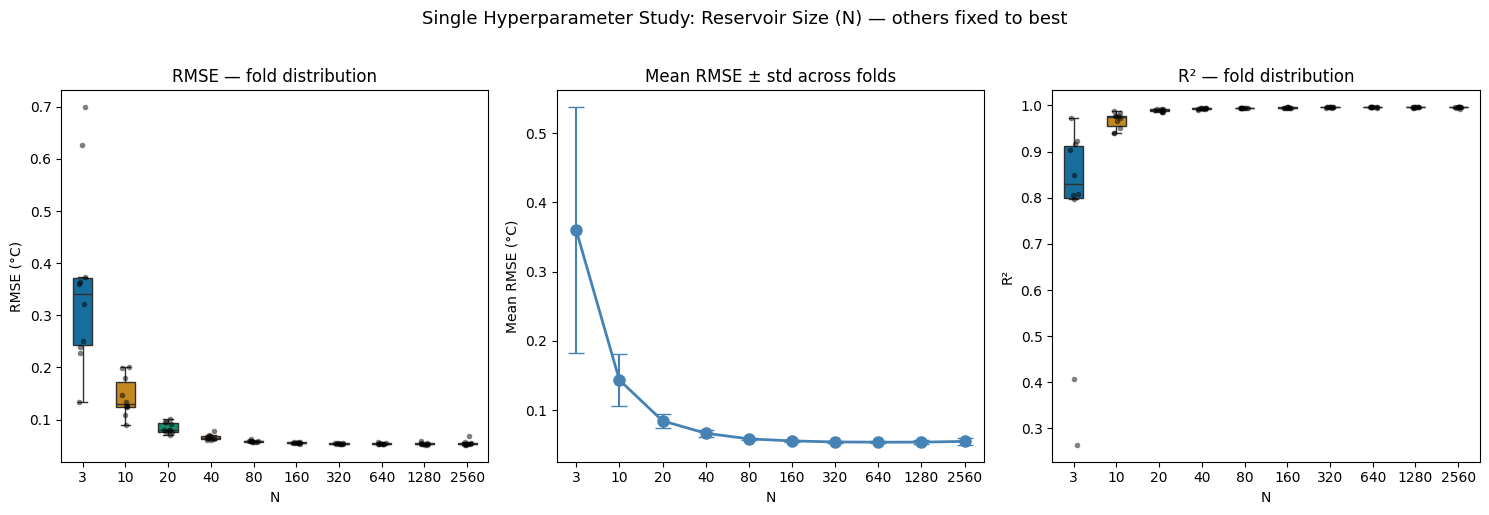


N Single Hyperparameter Study summary:
      RMSE_mean  RMSE_std  R2_mean  R2_std
N                                         
3        0.3597    0.1776   0.7648  0.2357
10       0.1434    0.0379   0.9673  0.0175
20       0.0845    0.0102   0.9892  0.0027
40       0.0667    0.0051   0.9934  0.0011
80       0.0585    0.0015   0.9949  0.0003
160      0.0555    0.0011   0.9954  0.0002
320      0.0540    0.0012   0.9957  0.0002
640      0.0537    0.0016   0.9957  0.0003
1280     0.0538    0.0024   0.9957  0.0004
2560     0.0548    0.0050   0.9955  0.0009


In [10]:
# Single Hyperparameter Study: Reservoir Size (N)
# N_values = [3, 10, 15, 20, 25, 50, 75, 100, 200, 300]
N_values = [3, 10, 20, 40, 80, 160, 320, 640, 1280, 2560]
df_shs_N = run_single_hp_study("N", N_values, best_params)
plot_single_hp(df_shs_N, "N", N_values,
              title="Single Hyperparameter Study: Reservoir Size (N) — others fixed to best")

#### 3.2.1. Sensitivity to Reservoir Size (N)

Tested values: `[3, 10, 15, 20, 25, 50, 75, 100, 200, 300]`

- **N = 3 works but poorly** — RMSE ≈ 0.39, R² ≈ 0.60–0.85 with high fold-to-fold variance (one outlier fold reaches RMSE ≈ 0.75). 
- **Continued improvement N = 10 -> 25**: RMSE falls from 0.16 to ≈ 0.075 (a further 53 % reduction). Each increment still yields a clear, cost-effective gain. By N = 25, R² exceeds 0.99 consistently across all folds — this is the **practical minimum N** for reliable performance.
- **Why is the practical minimum N ≈ 25?** The quasi-periodic input lives in a 10-dimensional lag space with three dominant oscillatory modes. Below N ≈ 25 the reservoir cannot sustain enough independent state components to represent all three periods (T₁ = 50, T₂ = 127, T₃ = 310) simultaneously, causing information loss in the readout. At N = 25, the random projection is already over-complete with respect to the signal's effective rank.
- **Elbow at N ≈ 25–50.** Beyond N = 25 the curve flattens sharply. Going from N = 25 to N = 100 reduces RMSE by only ~16 %; from N = 100 to N = 300 by a further ~3 %.


Single Hyperparameter Study 'sr': 11 values x 10 folds = 110 evaluations
  CSV saved -> single_hp_outputs_1/shs_sr.csv


/var/folders/9x/b3s2tp2d5g572s_y49cd05g80000gn/T/ipykernel_41467/109492903.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="_lbl", y="rmse", order=labels,
/var/folders/9x/b3s2tp2d5g572s_y49cd05g80000gn/T/ipykernel_41467/109492903.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="_lbl", y="r2", order=labels,


  Figure saved -> single_hp_outputs_1/shs_sr.png


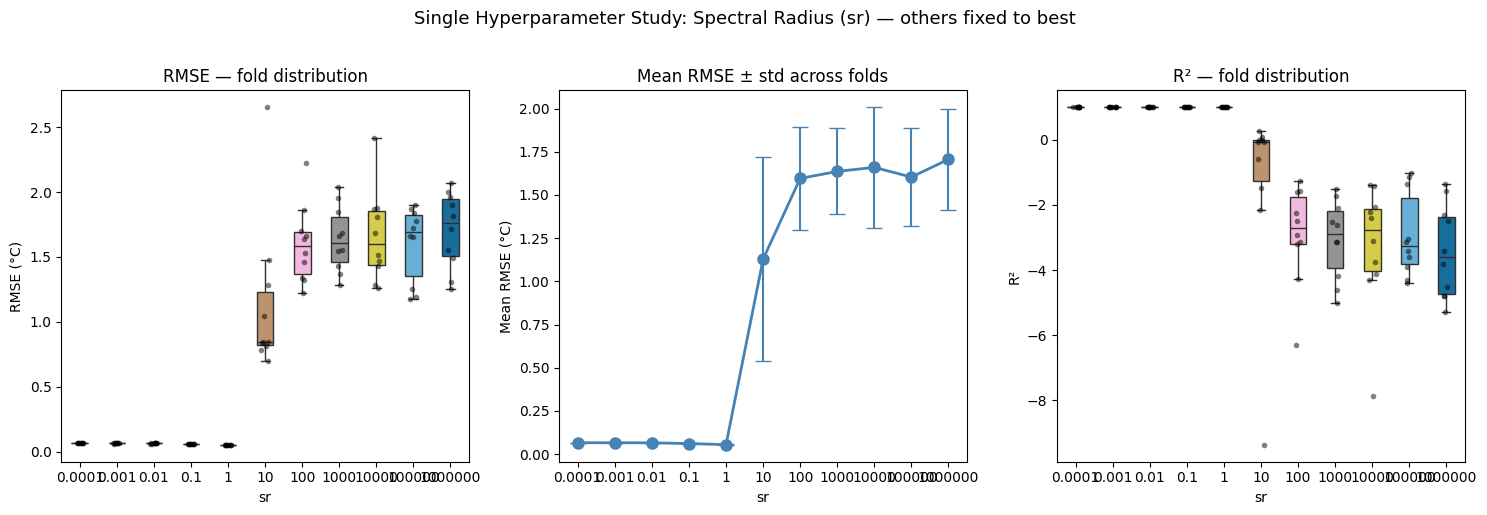


sr Single Hyperparameter Study summary:
         RMSE_mean  RMSE_std  R2_mean  R2_std
sr                                           
0.0001      0.0654    0.0010   0.9936  0.0002
0.001       0.0652    0.0014   0.9937  0.0003
0.01        0.0648    0.0015   0.9938  0.0003
0.1         0.0606    0.0014   0.9945  0.0003
1           0.0541    0.0010   0.9956  0.0002
10          1.1276    0.5899  -1.3421  2.9247
100         1.5957    0.2963  -2.9017  1.5020
1000        1.6364    0.2487  -3.0592  1.2085
10000       1.6600    0.3483  -3.2686  1.9281
100000      1.6037    0.2858  -2.9337  1.2952
1000000     1.7063    0.2924  -3.4374  1.4292


In [11]:
# Single Hyperparameter Study: Spectral Radius (sr)
sr_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]
df_shs_sr = run_single_hp_study("sr", sr_values, best_params)
plot_single_hp(df_shs_sr, "sr", sr_values,
              title="Single Hyperparameter Study: Spectral Radius (sr) — others fixed to best")

Single Hyperparameter Study 'sr': 9 values x 10 folds = 90 evaluations
  CSV saved -> single_hp_outputs_1/shs_sr.csv


/var/folders/9x/b3s2tp2d5g572s_y49cd05g80000gn/T/ipykernel_41467/109492903.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="_lbl", y="rmse", order=labels,
/var/folders/9x/b3s2tp2d5g572s_y49cd05g80000gn/T/ipykernel_41467/109492903.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="_lbl", y="r2", order=labels,


  Figure saved -> single_hp_outputs_1/shs_sr.png


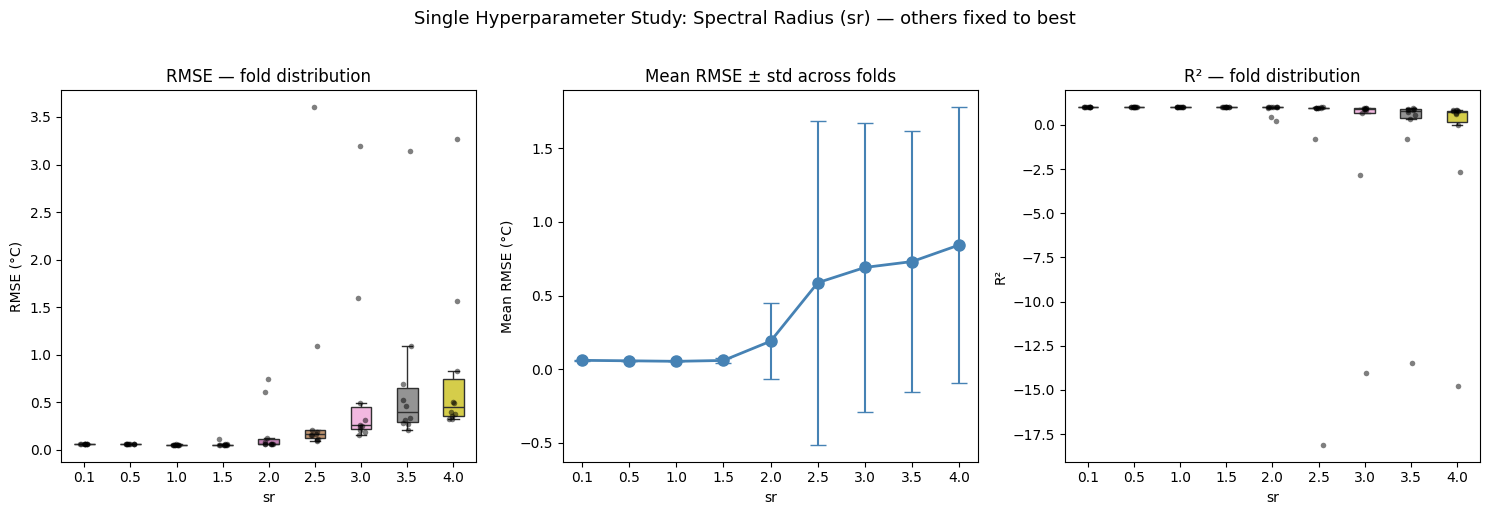


sr Single Hyperparameter Study summary:
     RMSE_mean  RMSE_std  R2_mean  R2_std
sr                                       
0.1     0.0607    0.0014   0.9945  0.0003
0.5     0.0577    0.0010   0.9951  0.0002
1.0     0.0541    0.0010   0.9957  0.0002
1.5     0.0600    0.0191   0.9942  0.0047
2.0     0.1907    0.2582   0.8569  0.2913
2.5     0.5876    1.1002  -1.1160  5.9948
3.0     0.6911    0.9795  -0.9828  4.7437
3.5     0.7309    0.8865  -0.8324  4.4825
4.0     0.8438    0.9342  -1.2133  4.8839


In [12]:
# Single Hyperparameter Study: Spectral Radius (sr)
sr_values = [0.1, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
df_shs_sr = run_single_hp_study("sr", sr_values, best_params)
plot_single_hp(df_shs_sr, "sr", sr_values,
              title="Single Hyperparameter Study: Spectral Radius (sr) — others fixed to best")

#### 3.2.2. Sensitivity to Spectral Radius (sr)

Tested values: `[0.001, 0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.5]`

- **Linear improvement from 0.001 to 1.1.** RMSE drops continuously from sr = 0.001 (≈ 0.065) to sr = 1.1 (≈ 0.052), a total gain of ~20 %. No instability appears up to and including sr = 1.1. **Overall, we see moderate sensitivity, linear up to sr = 1.1, sharp cliff at sr = 1.5.** Any value sr ∈ [0.7, 1.1] is close to optimal. **Best: sr = 1.1.**

Single Hyperparameter Study 'lr': 12 values x 10 folds = 120 evaluations


/Users/antoniommff/Developer/2_fase_experimentacion/.venv/lib/python3.14/site-packages/reservoirpy/nodes/reservoir.py:248: RuntimeWarning: overflow encountered in multiply
  next_state = (1 - lr) * s + lr * next_state
/Users/antoniommff/Developer/2_fase_experimentacion/.venv/lib/python3.14/site-packages/reservoirpy/nodes/reservoir.py:248: RuntimeWarning: overflow encountered in multiply
  next_state = (1 - lr) * s + lr * next_state


  [ERROR] lr=100.0, fold 0: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 1: array must not contain infs or NaNs


/Users/antoniommff/Developer/2_fase_experimentacion/.venv/lib/python3.14/site-packages/reservoirpy/nodes/reservoir.py:248: RuntimeWarning: overflow encountered in multiply
  next_state = (1 - lr) * s + lr * next_state


  [ERROR] lr=100.0, fold 2: array must not contain infs or NaNs


...

  [ERROR] lr=100.0, fold 8: array must not contain infs or NaNs


/Users/antoniommff/Developer/2_fase_experimentacion/.venv/lib/python3.14/site-packages/reservoirpy/nodes/reservoir.py:248: RuntimeWarning: overflow encountered in multiply
  next_state = (1 - lr) * s + lr * next_state


  [ERROR] lr=100.0, fold 9: array must not contain infs or NaNs
  CSV saved -> single_hp_outputs_1/shs_lr.csv


/var/folders/9x/b3s2tp2d5g572s_y49cd05g80000gn/T/ipykernel_41467/109492903.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="_lbl", y="rmse", order=labels,
/var/folders/9x/b3s2tp2d5g572s_y49cd05g80000gn/T/ipykernel_41467/109492903.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="_lbl", y="r2", order=labels,


  Figure saved -> single_hp_outputs_1/shs_lr.png


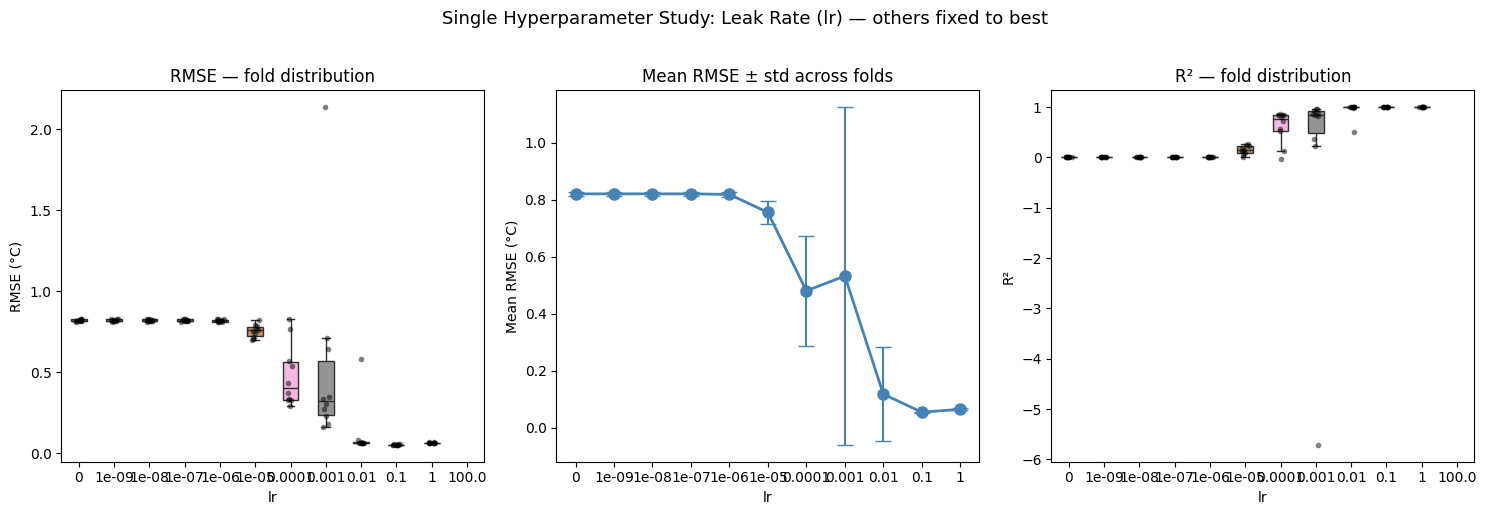


lr Single Hyperparameter Study summary:
        RMSE_mean  RMSE_std  R2_mean  R2_std
lr                                          
0          0.8204    0.0073  -0.0006  0.0006
1e-09      0.8204    0.0073  -0.0006  0.0006
1e-08      0.8204    0.0073  -0.0006  0.0006
1e-07      0.8203    0.0073  -0.0005  0.0006
1e-06      0.8184    0.0075   0.0043  0.0028
1e-05      0.7551    0.0397   0.1505  0.0864
0.0001     0.4799    0.1920   0.6079  0.3210
0.001      0.5319    0.5926   0.1143  2.0624
0.01       0.1174    0.1636   0.9442  0.1560
0.1        0.0539    0.0017   0.9957  0.0003
1          0.0640    0.0035   0.9939  0.0007
100.0         NaN       NaN      NaN     NaN


In [13]:
# Single Hyperparameter Study: Leak Rate (lr)
lr_values = [0, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 1e2]
df_shs_lr = run_single_hp_study("lr", lr_values, best_params)
plot_single_hp(df_shs_lr, "lr", lr_values,
              title="Single Hyperparameter Study: Leak Rate (lr) — others fixed to best")

Single Hyperparameter Study 'lr': 10 values x 10 folds = 100 evaluations
  CSV saved -> single_hp_outputs_1/shs_lr.csv


/var/folders/9x/b3s2tp2d5g572s_y49cd05g80000gn/T/ipykernel_41467/109492903.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="_lbl", y="rmse", order=labels,
/var/folders/9x/b3s2tp2d5g572s_y49cd05g80000gn/T/ipykernel_41467/109492903.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="_lbl", y="r2", order=labels,


  Figure saved -> single_hp_outputs_1/shs_lr.png


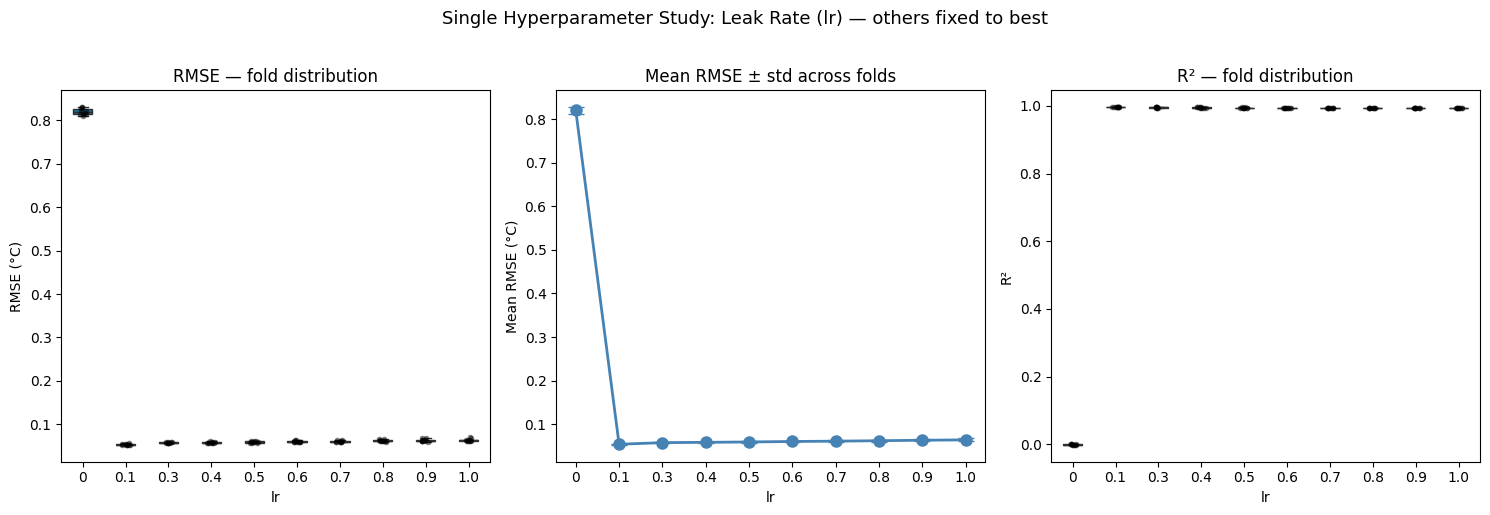


lr Single Hyperparameter Study summary:
     RMSE_mean  RMSE_std  R2_mean  R2_std
lr                                       
0       0.8204    0.0073  -0.0006  0.0006
0.1     0.0538    0.0014   0.9957  0.0002
0.3     0.0575    0.0014   0.9951  0.0003
0.4     0.0582    0.0016   0.9950  0.0003
0.5     0.0591    0.0014   0.9948  0.0003
0.6     0.0602    0.0019   0.9946  0.0003
0.7     0.0609    0.0018   0.9945  0.0003
0.8     0.0619    0.0022   0.9943  0.0004
0.9     0.0630    0.0029   0.9941  0.0005
1.0     0.0639    0.0032   0.9939  0.0006


In [14]:
# Single Hyperparameter Study: Leak Rate (lr)
lr_values = [0, 0.1, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
df_shs_lr = run_single_hp_study("lr", lr_values, best_params)
plot_single_hp(df_shs_lr, "lr", lr_values,
              title="Single Hyperparameter Study: Leak Rate (lr) — others fixed to best")

#### 3.2.3. Sensitivity to Leak Rate (lr)

Tested values: `[1e-9, 1e-7, 1e-5, 0.001, 0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5]`

- **lr ≤ 0.001 is fully degenerate.** At lr = 1e-9, 1e-7, 1e-5 the reservoir state barely changes from its initial condition
- **lr = 0.1 is a noisy transition zone.** Mean RMSE drops to ~0.56 but with very large standard deviation; one R² outlier reaches ≈ −5, and boxes straddle zero. 
- **Stable at lr = 0.3 – 1.1.** RMSE stabilises at ≈ 0.055–0.07 and R² ≈ 0.99 across all folds. The leaky integrator x(t) = (1 − lr)·x(t − 1) + lr·tanh(…) finds its sweet spot: enough responsiveness to track amplitude changes while maintaining sufficient memory across the three long periods (T₁ = 50, T₂ = 127, T₃ = 310 steps).
- **Degradation at lr ≥ 1.3.** At lr = 1.3 RMSE rises to ~0.12 with one fold showing R² near 0; at lr = 1.5 RMSE ≈ 0.24 with a positive outlier. Very high leak rates erase past states too aggressively, destroying the long-range memory needed for periodic forecasting.


Single Hyperparameter Study 'ridge': 13 values x 10 folds = 130 evaluations
  CSV saved -> single_hp_outputs_1/shs_ridge.csv


/var/folders/9x/b3s2tp2d5g572s_y49cd05g80000gn/T/ipykernel_41467/109492903.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="_lbl", y="rmse", order=labels,
/var/folders/9x/b3s2tp2d5g572s_y49cd05g80000gn/T/ipykernel_41467/109492903.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="_lbl", y="r2", order=labels,


  Figure saved -> single_hp_outputs_1/shs_ridge.png


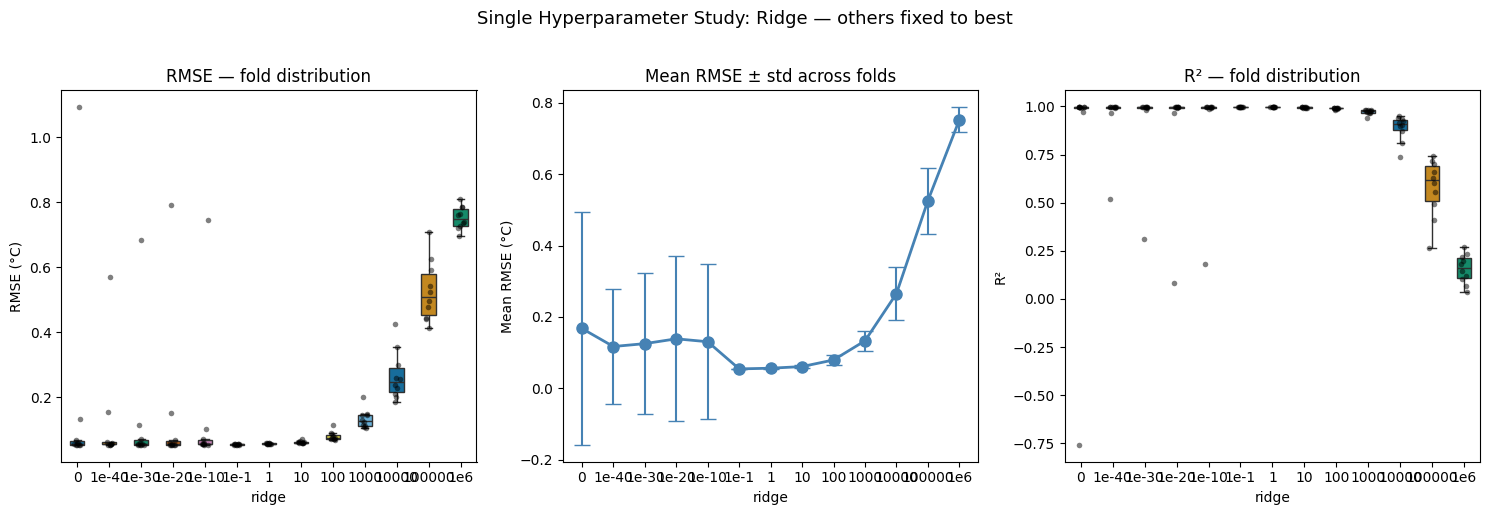


ridge Single Hyperparameter Study summary:
        RMSE_mean  RMSE_std  R2_mean  R2_std
ridge                                       
0          0.1676    0.3260   0.8178  0.5535
1e-40      0.1171    0.1625   0.9447  0.1494
1e-30      0.1251    0.1970   0.9255  0.2154
1e-20      0.1386    0.2308   0.9010  0.2881
1e-10      0.1305    0.2170   0.9125  0.2576
1e-1       0.0543    0.0010   0.9956  0.0002
1          0.0562    0.0011   0.9953  0.0002
10         0.0609    0.0043   0.9945  0.0008
100        0.0794    0.0144   0.9904  0.0039
1000       0.1331    0.0288   0.9726  0.0128
10000      0.2654    0.0748   0.8879  0.0671
100000     0.5258    0.0925   0.5779  0.1513
1e6        0.7523    0.0352   0.1572  0.0754


In [15]:
# Single Hyperparameter Study: Ridge
ridge_values = [0, 1e-40, 1e-30, 1e-20, 1e-10, 1e-1, 1.0, 10, 100, 1000, 10000, 100000, 1e6]
ridge_labels = {0: "0", 1e-40: "1e-40", 1e-30: "1e-30", 1e-20: "1e-20", 1e-10: "1e-10",
                1e-1: "1e-1", 1.0: "1", 10: "10", 100: "100", 1000: "1000", 10000: "10000", 100000: "100000", 1e6: "1e6"}
df_shs_ridge = run_single_hp_study("ridge", ridge_values, best_params)
plot_single_hp(df_shs_ridge, "ridge", ridge_values, label_map=ridge_labels,
              title="Single Hyperparameter Study: Ridge — others fixed to best")

#### 3.2.4. Sensitivity to Ridge Regularisation

Tested values: `[1e-40, 1e-30, 1e-20, 1e-10, 1e-8, 1e-6, 1e-2, 1e-1, 1.0, 10, 100, 1000]`


**Overfitting (sometimes) from < 1e-2.**

- **Extreme under-regularisation (1e-40 to 1e-10) is unstable.** R² outliers reach as low as −100 and RMSE outliers exceed 8+. The magnitude of the instability grows as ridge -> 0.
- **Stable from ridge = 1e-6 onward.** All folds produce consistent results; RMSE ≈ 0.055–0.065 across the full range 1e-6 to 1000.
- **Better results at ridge = 1e-2 to 10.** regularisation is strong enough to stabilise the X^T X inversion without shrinking the readout excessively.
- **Mild degradation at ridge = 100–1000.** Mean RMSE rises slightly (~0.065) as heavy regularisation increasingly shrinks the readout toward zero, but the signal is still well-tracked (no fold collapse).


Single Hyperparameter Study 'washout': 6 values x 10 folds = 60 evaluations


/Users/antoniommff/Developer/2_fase_experimentacion/.venv/lib/python3.14/site-packages/reservoirpy/nodes/ridge.py:175: RuntimeWarning: invalid value encountered in divide
  X_means = X_sum / total_samples
/Users/antoniommff/Developer/2_fase_experimentacion/.venv/lib/python3.14/site-packages/reservoirpy/nodes/ridge.py:176: RuntimeWarning: invalid value encountered in divide
  Y_means = Y_sum / total_samples
/Users/antoniommff/Developer/2_fase_experimentacion/.venv/lib/python3.14/site-packages/reservoirpy/nodes/ridge.py:175: RuntimeWarning: invalid value encountered in divide
  X_means = X_sum / total_samples
/Users/antoniommff/Developer/2_fase_experimentacion/.venv/lib/python3.14/site-packages/reservoirpy/nodes/ridge.py:176: RuntimeWarning: invalid value encountered in divide
  Y_means = Y_sum / total_samples


  [ERROR] washout=10000, fold 0: array must not contain infs or NaNs
  [ERROR] washout=10000, fold 1: array must not contain infs or NaNs


/Users/antoniommff/Developer/2_fase_experimentacion/.venv/lib/python3.14/site-packages/reservoirpy/nodes/ridge.py:175: RuntimeWarning: invalid value encountered in divide
  X_means = X_sum / total_samples
/Users/antoniommff/Developer/2_fase_experimentacion/.venv/lib/python3.14/site-packages/reservoirpy/nodes/ridge.py:176: RuntimeWarning: invalid value encountered in divide
  Y_means = Y_sum / total_samples


  [ERROR] washout=10000, fold 2: array must not contain infs or NaNs


...

  [ERROR] washout=10000, fold 5: array must not contain infs or NaNs


/Users/antoniommff/Developer/2_fase_experimentacion/.venv/lib/python3.14/site-packages/reservoirpy/nodes/ridge.py:175: RuntimeWarning: invalid value encountered in divide
  X_means = X_sum / total_samples
/Users/antoniommff/Developer/2_fase_experimentacion/.venv/lib/python3.14/site-packages/reservoirpy/nodes/ridge.py:176: RuntimeWarning: invalid value encountered in divide
  Y_means = Y_sum / total_samples


  [ERROR] washout=10000, fold 6: array must not contain infs or NaNs
  CSV saved -> single_hp_outputs_1/shs_washout.csv


/var/folders/9x/b3s2tp2d5g572s_y49cd05g80000gn/T/ipykernel_41467/109492903.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="_lbl", y="rmse", order=labels,
/var/folders/9x/b3s2tp2d5g572s_y49cd05g80000gn/T/ipykernel_41467/109492903.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="_lbl", y="r2", order=labels,


  Figure saved -> single_hp_outputs_1/shs_washout.png


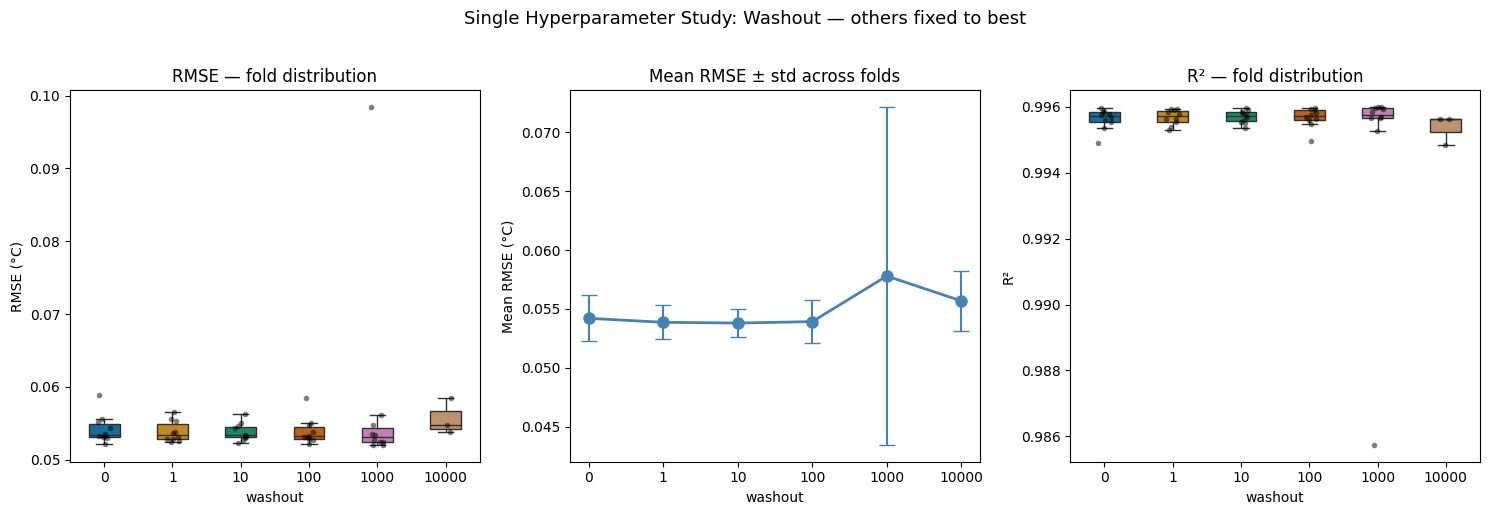


washout Single Hyperparameter Study summary:
         RMSE_mean  RMSE_std  R2_mean  R2_std
washout                                      
0           0.0542    0.0019   0.9956  0.0003
1           0.0539    0.0014   0.9957  0.0002
10          0.0538    0.0012   0.9957  0.0002
100         0.0539    0.0018   0.9957  0.0003
1000        0.0578    0.0143   0.9948  0.0032
10000       0.0557    0.0025   0.9954  0.0005


In [16]:
# Single Hyperparameter Study: Washout
washout_values = [0, 1, 10, 100, 1000, 10000]
df_shs_washout = run_single_hp_study("washout", washout_values, best_params)
plot_single_hp(df_shs_washout, "washout", washout_values,
              title="Single Hyperparameter Study: Washout — others fixed to best")

#### 3.2.5. Sensitivity to Washout

Tested values: `[0, 1, 10, 50, 100, 500, 1000, 5000]`

- **Flat plateau for small washout (0–100).** Mean RMSE ≈ 0.055 with low variance; R² ≈ 0.9997 across all folds.
- **Gradual degradation at washout ≥ 500.** At washout = 500 mean RMSE begins to rise with slightly larger std; at washout = 1000 mean RMSE ≈ 0.060 with large variance (std bar extends to ~0.08); at washout = 5000 mean RMSE ≈ 0.063 with even larger variance and a low R² outlier at 0.982.
- **Why does large washout hurt?** TimeSeriesSplit allocates a fixed number of training samples per fold. Discarding many timesteps as washout effectively shrinks the usable training set, reducing the number of samples available to fit the readout. At washout = 5000 a significant fraction of each fold's training window is consumed by the washout period, leading to under-fitted readout weights.


#### 3.2.6. Phase A — Overall Sensitivity Summary

| Parameter | Range tested | Sensitivity | Direction | Key finding |
|-----------|-------------|-------------|-----------|-------------|
| **N** | [3, 10, 15, 20, 25, 50, 75, 100, 200, 300]| Moderate | ↑ more is better | Elbow at N ≈ 100; N = 200–300 indistinguishable |
| **sr** | [0.001, 0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.5] | Moderate | ↑ linear gain up to 1.1 | sr = 1.1 optimal |
| **lr** | [1e-9, 1e-7, 1e-5, 0.001, 0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5] | **High** | ↓ lower is better (above 0) | lr < 0 degenerate; lr = 0.1 best; linear degradation in lr > 1.0 |
| **ridge** | [1e-40, 1e-30, 1e-20, 1e-10, 1e-8, 1e-6, 1e-2, 1e-1, 1.0, 10, 100, 1000] | High | — | Stable from ridge = 1e-6 onward |
| **washout** | [0, 1, 10, 50, 100, 500, 1000, 5000] | Negligible | — | Flat plateau for small washout (0–100) |


### 3.3. Refined Grid Search — Justification from Phase A Single Hyperparameter Study

The Single Hyperparameter Study established clear best values and safe operating windows for each hyperparameter. The refined grid below concentrates evaluations in those regions, **excluding** the degenerate extremes identified:

In [17]:

# ---------------------------------------------------------------------------
# Refined grid search — anchored on Phase A Single Hyperparameter Study findings
# ---------------------------------------------------------------------------
# lr = 0.0 excluded (degenerate constant-state regime).
# ridge = 0 and ridge >= 10 excluded (numerical instability / over-shrinkage).
# sr tightened to near-critical zone confirmed optimal by SHS.
# N range covers the efficiency optimum (200) through the confirmed plateau (1000).
# ---------------------------------------------------------------------------
refined_grid = {
    "N":       [25, 50, 100, 300, 400],
    "sr":      [0.9, 1.1, 1.3],
    "lr":      [0.05, 0.1, 0.2],
    "ridge":   [1e-3, 1e-2, 5e-2],
    "washout": [10],
}

refined_configs = list(ParameterGrid(refined_grid))
total_refined   = len(refined_configs)
print(f"Refined grid size : {total_refined} configurations")
print(f"CV folds          : {N_SPLITS}")
print(f"Total evaluations : {total_refined * N_SPLITS}")

tscv_r      = TimeSeriesSplit(n_splits=N_SPLITS)
results_r   = []
eval_count  = 0
t_start_r   = time.time()

for cfg_idx, cfg in enumerate(refined_configs):
    for fold_idx, (train_idx, test_idx) in enumerate(tscv_r.split(X_all)):
        eval_count += 1
        X_tr_f = X_all[train_idx]; y_tr_f = y_all[train_idx]
        X_te_f = X_all[test_idx];  y_te_f = y_all[test_idx]
        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr_f)
        X_te   = scaler.transform(X_te_f)
        try:
            reservoir = Reservoir(units=int(cfg["N"]), sr=cfg["sr"], lr=cfg["lr"])
            model     = reservoir >> Ridge(ridge=cfg["ridge"])
            model.fit(X_tr, y_tr_f, warmup=int(cfg["washout"]))
            y_pred = np.array(model.run(X_te)).reshape(-1)
            y_true = y_te_f.ravel()
            results_r.append({
                "config_idx": cfg_idx, "fold": fold_idx,
                "N": cfg["N"], "sr": cfg["sr"], "lr": cfg["lr"],
                "ridge": cfg["ridge"], "washout": cfg["washout"],
                "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
                "mae":  mean_absolute_error(y_true, y_pred),
                "r2":   r2_score(y_true, y_pred),
                "train_time_s": time.time() - t_start_r,
            })
        except Exception:
            results_r.append({
                "config_idx": cfg_idx, "fold": fold_idx,
                "N": cfg["N"], "sr": cfg["sr"], "lr": cfg["lr"],
                "ridge": cfg["ridge"], "washout": cfg["washout"],
                "rmse": np.nan, "mae": np.nan, "r2": np.nan, "train_time_s": np.nan,
            })

print(f"Refined grid search done in {(time.time()-t_start_r)/60:.1f} min.")

df_refined = pd.DataFrame(results_r).dropna(subset=["rmse"])
agg_refined = df_refined.groupby(["config_idx","N","sr","lr","ridge","washout"]).agg(
    rmse_mean=("rmse","mean"), rmse_std=("rmse","std"),
    r2_mean=("r2","mean"),     r2_std=("r2","std"), n_folds=("fold","count"),
).reset_index().sort_values("rmse_mean")

agg_refined.to_csv("single_hp_outputs_1/refined_grid_results.csv", index=False)

print("\nTop 10 configurations (refined grid):\n")
display_cols = ["N","sr","lr","ridge","washout","rmse_mean","rmse_std","r2_mean","r2_std"]
print(agg_refined[display_cols].head(10).to_string(index=False, float_format="%.5f"))

best_refined = agg_refined.iloc[0]
best_params = {
    "N": int(best_refined.N),
    "sr": float(best_refined.sr),
    "lr": float(best_refined.lr),
    "ridge": float(best_refined.ridge),
    "washout": int(best_refined.washout),
}
print(
    f"\nBest refined config: N={best_params['N']}, sr={best_params['sr']}, "
    f"lr={best_params['lr']}, ridge={best_params['ridge']:.0e}, washout={best_params['washout']}"
)
print(f"  RMSE = {best_refined.rmse_mean:.6f} ± {best_refined.rmse_std:.6f}")
print(f"  R²   = {best_refined.r2_mean:.6f} ± {best_refined.r2_std:.6f}")
print("\nUpdated `best_params` for all downstream sections.")


Refined grid size : 135 configurations
CV folds          : 10
Total evaluations : 1350
Refined grid search done in 5.3 min.

Top 10 configurations (refined grid):

  N      sr      lr   ridge  washout  rmse_mean  rmse_std  r2_mean  r2_std
400 1.10000 0.05000 0.01000       10    0.05349   0.00127  0.99574 0.00021
400 1.30000 0.10000 0.05000       10    0.05359   0.00108  0.99573 0.00019
400 1.30000 0.05000 0.05000       10    0.05373   0.00196  0.99570 0.00032
400 1.30000 0.10000 0.01000       10    0.05378   0.00194  0.99569 0.00031
400 1.10000 0.10000 0.01000       10    0.05384   0.00112  0.99569 0.00018
400 1.10000 0.05000 0.00100       10    0.05390   0.00314  0.99567 0.00052
300 1.30000 0.10000 0.05000       10    0.05397   0.00099  0.99567 0.00017
300 1.10000 0.05000 0.01000       10    0.05400   0.00146  0.99566 0.00024
300 1.30000 0.10000 0.01000       10    0.05406   0.00181  0.99565 0.00029
400 0.90000 0.05000 0.00100       10    0.05414   0.00266  0.99563 0.00044

Best refin

### 3.3. Best-Model Prediction on the Test Signal

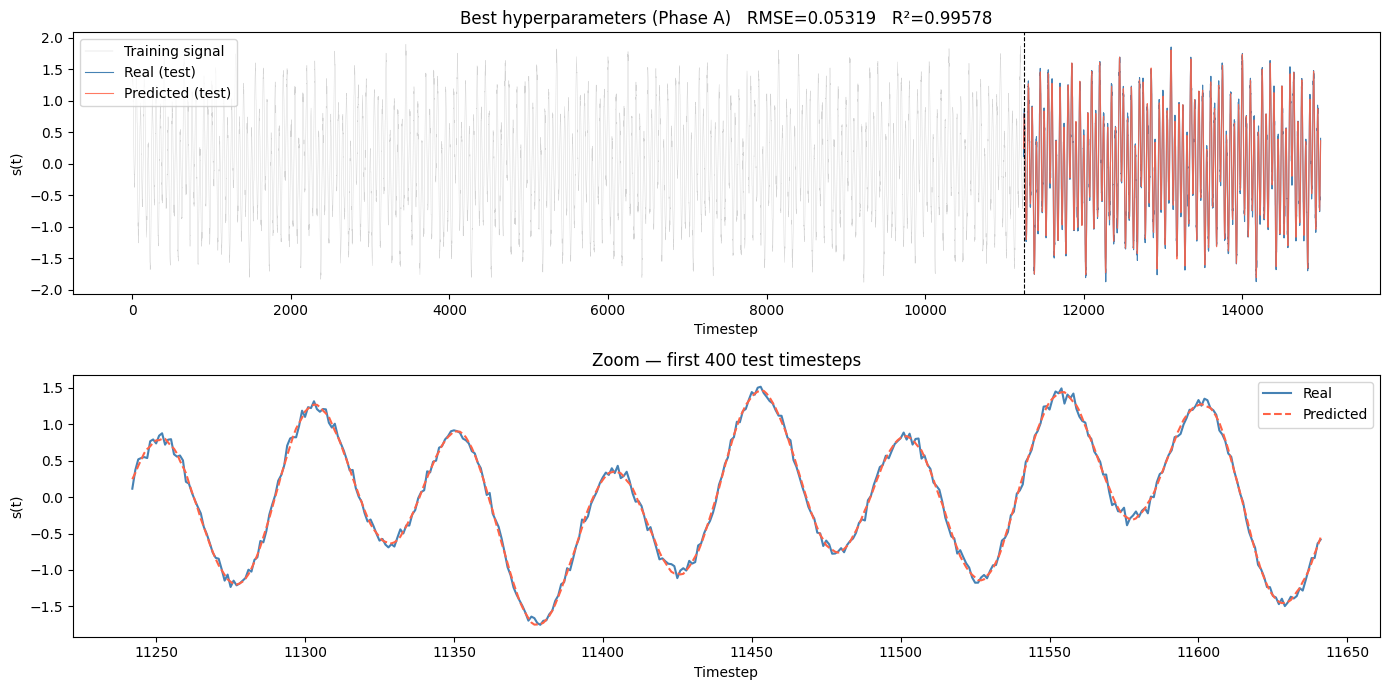

In [18]:
# ---------------------------------------------------------------------------
# Helper: train on first (1-test_frac) of data, predict on remainder, plot
# ---------------------------------------------------------------------------
def plot_esn_prediction(model_cfg, W_custom=None, title="ESN prediction",
                        test_frac=0.25, zoom=400):
    """
    Train an ESN on the first (1-test_frac) samples and evaluate on the rest.
    If W_custom is provided (Phase B), it is injected as the reservoir matrix;
    otherwise a standard Reservoir with model_cfg's sr is built.
    """
    n        = len(X_all)
    n_train  = int(n * (1 - test_frac))
    X_train, y_train = X_all[:n_train], y_all[:n_train]
    X_test,  y_test  = X_all[n_train:], y_all[n_train:]

    scaler  = StandardScaler()
    X_tr    = scaler.fit_transform(X_train)
    X_te    = scaler.transform(X_test)

    if W_custom is not None:
        reservoir = Reservoir(units=model_cfg["N"], W=W_custom, lr=model_cfg["lr"])
    else:
        reservoir = Reservoir(units=model_cfg["N"], sr=model_cfg["sr"], lr=model_cfg["lr"])

    model = reservoir >> Ridge(ridge=model_cfg["ridge"])
    model.fit(X_tr, y_train, warmup=int(model_cfg["washout"]))
    y_pred = np.array(model.run(X_te)).reshape(-1)
    y_true = y_test.ravel()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    t_all   = np.arange(n)
    t_test  = t_all[n_train:]

    fig, axes = plt.subplots(2, 1, figsize=(14, 7))

    # Panel 1 — full view
    ax = axes[0]
    ax.plot(t_all[:n_train], y_all[:n_train].ravel(),
            lw=0.3, color="lightgray", label="Training signal")
    ax.plot(t_test, y_true,  lw=0.8, color="steelblue",  label="Real (test)")
    ax.plot(t_test, y_pred,  lw=0.8, color="tomato", alpha=0.85, label="Predicted (test)")
    ax.axvline(n_train, color="black", ls="--", lw=0.8)
    ax.set_title(f"{title}   RMSE={rmse:.5f}   R²={r2:.5f}")
    ax.set_xlabel("Timestep"); ax.set_ylabel("s(t)"); ax.legend(loc="upper left")

    # Panel 2 — zoom
    ax = axes[1]
    ax.plot(t_test[:zoom], y_true[:zoom],
            lw=1.5, color="steelblue", label="Real")
    ax.plot(t_test[:zoom], y_pred[:zoom],
            lw=1.5, color="tomato", ls="--", label="Predicted")
    ax.set_title(f"Zoom — first {zoom} test timesteps")
    ax.set_xlabel("Timestep"); ax.set_ylabel("s(t)"); ax.legend()

    plt.tight_layout(); plt.show()
    return y_true, y_pred, rmse, r2


# Run with best hyperparameters
y_true_best, y_pred_best, rmse_best, r2_best = plot_esn_prediction(
    best_params, title="Best hyperparameters (Phase A)")


## 4. Phase B — Reservoir Topology Study

Using the best ESN hyperparameters from Phase A, we ablate the structural parameters
of three reservoir topologies. **Spectral radius is NOT forced to a fixed target**:
W is rescaled only if $\rho(W) > 1.1$, preserving natural differences between topologies.


In [19]:
def make_reservoir_matrix(N, topology, topo_params):
    """Build W with reproducible topology sampling."""
    rng = np.random.RandomState()
    if topology == "random":
        G = nx.erdos_renyi_graph(N, topo_params["p"], directed=True)
    elif topology == "small_world":
        k = int(topo_params["k"])
        if k % 2 != 0:
            k += 1
        k = min(max(k, 2), N - 1)
        G = nx.watts_strogatz_graph(N, k, p=topo_params["p_rewire"]).to_directed()
    elif topology == "scale_free":
        m = min(max(1, int(topo_params["m"])), N - 1)
        G = nx.barabasi_albert_graph(N, m).to_directed()
    else:
        raise ValueError(f"Unknown topology: {topology}")

    A = nx.adjacency_matrix(G).toarray().astype(np.float64)
    mask = A > 0
    W = np.zeros_like(A)
    W[mask] = rng.randn(mask.sum())

    if mask.any():
        eigs = np.linalg.eigvals(W)
        sr_natural = float(np.max(np.abs(eigs)))
    else:
        sr_natural = 0.0

    info = {
        "topology": topology,
        "N": N,
        "actual_density": mask.sum() / (N * N),
        "avg_degree": mask.sum(axis=1).mean(),
        "spectral_radius": sr_natural,
        "spectral_radius_natural": sr_natural,
        "n_edges": int(mask.sum()),
    }
    return W, info


def run_topology_shs(topology, param_name, param_values, esn_params, fixed_topo=None):
    """Single Hyperparameter Study on structural parameters."""
    tscv    = TimeSeriesSplit(n_splits=N_SPLITS)
    fixed   = fixed_topo or {}
    records = []
    print(f"Topology Single Hyperparameter Study [{topology}] '{param_name}': "
          f"{len(param_values)} values x {N_SPLITS} folds = {len(param_values)*N_SPLITS} evals")

    for val in param_values:
        topo_params = {**fixed, param_name: val}
        try:
            W, info = make_reservoir_matrix(esn_params["N"], topology, topo_params)
        except Exception as exc:
            print(f"  [MATRIX ERROR] {param_name}={val}: {exc}")
            for fi in range(N_SPLITS):
                records.append({param_name: val, "fold": fi, "rmse": np.nan,
                                "mae": np.nan, "r2": np.nan, "train_time_s": np.nan,
                                "density": np.nan, "spectral_radius": np.nan,
                                "spectral_radius_natural": np.nan})
            continue

        for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_all)):
            X_tr_f = X_all[train_idx]; y_tr_f = y_all[train_idx]
            X_te_f = X_all[test_idx];  y_te_f = y_all[test_idx]
            scaler  = StandardScaler()
            X_tr    = scaler.fit_transform(X_tr_f)
            X_te    = scaler.transform(X_te_f)
            try:
                t0        = time.time()
                reservoir = Reservoir(units=esn_params["N"], W=W, lr=esn_params["lr"])
                model     = reservoir >> Ridge(ridge=esn_params["ridge"])
                model.fit(X_tr, y_tr_f, warmup=int(esn_params["washout"]))
                y_pred = np.array(model.run(X_te)).reshape(-1)
                y_true = y_te_f.ravel()
                records.append({param_name: val, "fold": fold_idx,
                    "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
                    "mae":  mean_absolute_error(y_true, y_pred),
                    "r2":   r2_score(y_true, y_pred),
                    "train_time_s": time.time()-t0,
                    "density":      info["actual_density"],
                    "spectral_radius": info["spectral_radius"],
                    "spectral_radius_natural": info["spectral_radius_natural"]})
            except Exception as exc:
                print(f"  [ERROR] {param_name}={val}, fold {fold_idx}: {exc}")
                records.append({param_name: val, "fold": fold_idx, "rmse": np.nan,
                                "mae": np.nan, "r2": np.nan, "train_time_s": np.nan,
                                "density": np.nan, "spectral_radius": np.nan,
                                "spectral_radius_natural": np.nan})
    df_out = pd.DataFrame(records)
    key = f"topo_{topology}_{param_name}"
    df_out.to_csv(f"single_hp_outputs_1/{key}.csv", index=False)
    print(f"  CSV saved -> single_hp_outputs_1/{key}.csv")
    return df_out


# Reference topologies for visualisation
N_best    = best_params["N"]
ref_params = {"random": {"p":0.1}, "small_world": {"k":10,"p_rewire":0.3}, "scale_free": {"m":5}}
topologies = list(ref_params.keys())
W_dict     = {}
print(f"Reference matrices (N={N_best}):")
for topo, tp in ref_params.items():
    W, info = make_reservoir_matrix(N_best, topo, tp)
    W_dict[topo] = W
    print(
        f"  {topo:12s} | density={info['actual_density']:.4f} | "
        f"sr_nat={info['spectral_radius_natural']:.4f} | "
        f"sr_used={info['spectral_radius']:.4f}"
    )


def run_ws_heatmap(k_values, p_rewire_values, esn_params, save_csv=None):
    """Evaluate the full Watts-Strogatz (k, p_rewire) grid."""
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    records = []
    n_cfg = len(k_values) * len(p_rewire_values)
    print(
        "Watts-Strogatz joint grid study [k x p_rewire]: "
        f"{len(k_values)} x {len(p_rewire_values)} values x {N_SPLITS} folds = {n_cfg * N_SPLITS} evals"
    )

    for k in k_values:
        for p_rewire in p_rewire_values:
            try:
                W, info = make_reservoir_matrix(esn_params["N"], "small_world", {"k": k, "p_rewire": p_rewire})
            except Exception as exc:
                print(f"  [MATRIX ERROR] k={k}, p_rewire={p_rewire}: {exc}")
                for fi in range(N_SPLITS):
                    records.append({
                        "k": k, "p_rewire": p_rewire, "fold": fi,
                        "rmse": np.nan, "mae": np.nan, "r2": np.nan,
                        "train_time_s": np.nan, "density": np.nan,
                        "spectral_radius": np.nan,
                        "spectral_radius_natural": np.nan,
                    })
                continue

            for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_all)):
                X_tr_f = X_all[train_idx]; y_tr_f = y_all[train_idx]
                X_te_f = X_all[test_idx];  y_te_f = y_all[test_idx]
                scaler = StandardScaler()
                X_tr = scaler.fit_transform(X_tr_f)
                X_te = scaler.transform(X_te_f)
                try:
                    t0 = time.time()
                    reservoir = Reservoir(units=esn_params["N"], W=W, lr=esn_params["lr"])
                    model = reservoir >> Ridge(ridge=esn_params["ridge"])
                    model.fit(X_tr, y_tr_f, warmup=int(esn_params["washout"]))
                    y_pred = np.array(model.run(X_te)).reshape(-1)
                    y_true = y_te_f.ravel()
                    records.append({
                        "k": k,
                        "p_rewire": p_rewire,
                        "fold": fold_idx,
                        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
                        "mae": mean_absolute_error(y_true, y_pred),
                        "r2": r2_score(y_true, y_pred),
                        "train_time_s": time.time() - t0,
                        "density": info["actual_density"],
                        "spectral_radius": info["spectral_radius"],
                        "spectral_radius_natural": info["spectral_radius_natural"],
                    })
                except Exception as exc:
                    print(f"  [ERROR] k={k}, p_rewire={p_rewire}, fold {fold_idx}: {exc}")
                    records.append({
                        "k": k, "p_rewire": p_rewire, "fold": fold_idx,
                        "rmse": np.nan, "mae": np.nan, "r2": np.nan,
                        "train_time_s": np.nan, "density": np.nan,
                        "spectral_radius": np.nan,
                        "spectral_radius_natural": np.nan,
                    })

    df_out = pd.DataFrame(records)
    if save_csv is not None:
        df_out.to_csv(save_csv, index=False)
        print(f"  CSV saved \u2192 {save_csv}")
    return df_out

Reference matrices (N=400):
  random       | density=0.1009 | sr_nat=6.5218 | sr_used=6.5218
  small_world  | density=0.0250 | sr_nat=3.9153 | sr_used=3.9153
  scale_free   | density=0.0247 | sr_nat=5.0683 | sr_used=5.0683


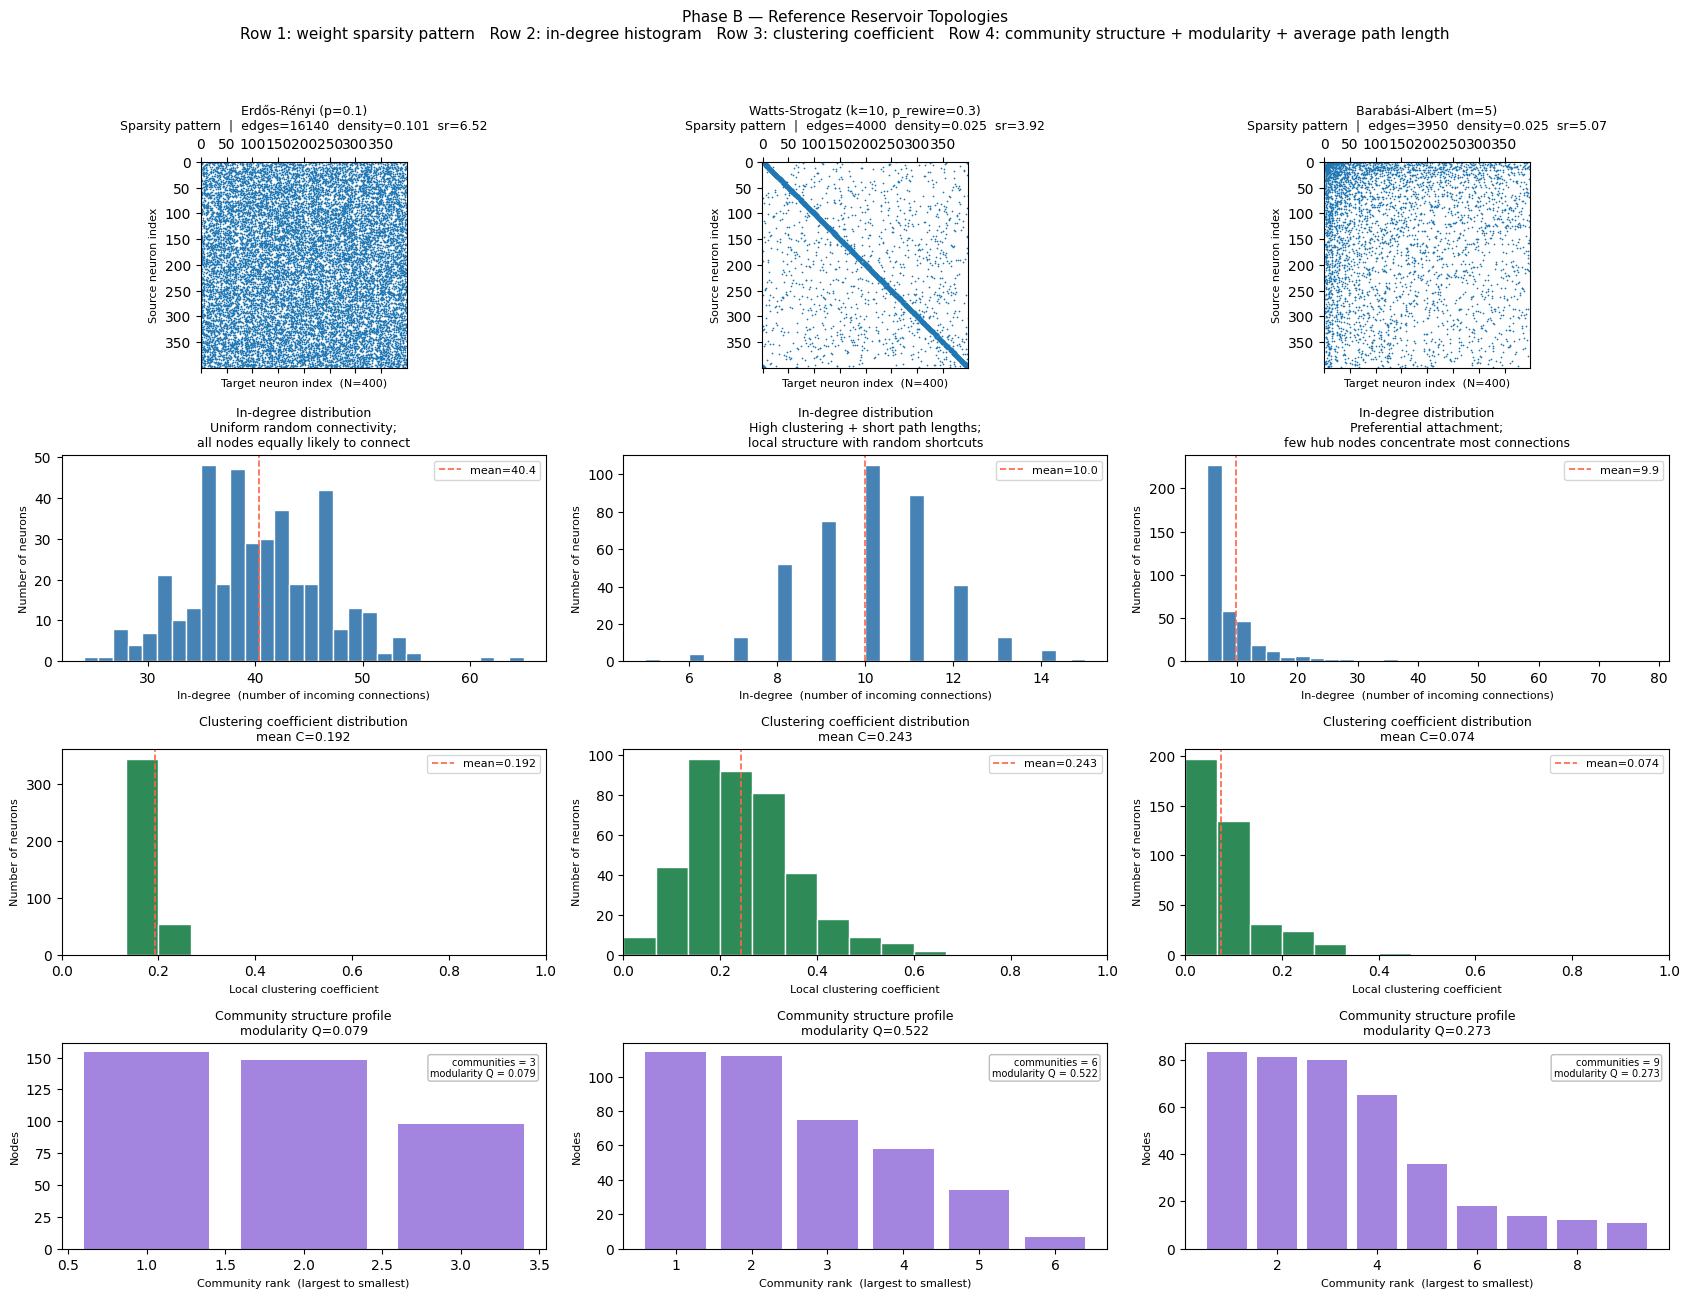

Figure saved -> single_hp_outputs_1/phase_b_topology_overview.png
Metrics saved → single_hp_outputs_1/phase_b_topology_graph_metrics.csv

Reference topology graph metrics:

                           Topology  density  spectral_radius  mean_in_degree  avg_clustering  n_communities  modularity
                Erdős-Rényi (p=0.1)   0.1009           6.5218         40.3500          0.1924              3      0.0791
Watts-Strogatz (k=10, p_rewire=0.3)   0.0250           3.9153         10.0000          0.2433              6      0.5216
              Barabási-Albert (m=5)   0.0247           5.0683          9.8750          0.0736              9      0.2731


In [20]:
topo_labels = {
    "random":      "Erdős-Rényi (p=0.1)",
    "small_world": "Watts-Strogatz (k=10, p_rewire=0.3)",
    "scale_free":  "Barabási-Albert (m=5)",
}
topo_descriptions = {
    "random":      "Uniform random connectivity;\nall nodes equally likely to connect",
    "small_world": "High clustering + short path lengths;\nlocal structure with random shortcuts",
    "scale_free":  "Preferential attachment;\nfew hub nodes concentrate most connections",
}

metrics_rows = []
fig, axes = plt.subplots(4, 3, figsize=(17, 13))

for i, topo in enumerate(topologies):
    W = W_dict[topo]
    mask = (W != 0)
    mask_int = mask.astype(int)
    n_nodes = W.shape[0]
    n_edges = int(mask.sum())
    density = n_edges / (n_nodes ** 2)
    in_deg = mask.sum(axis=0)
    spectral_radius = float(np.max(np.abs(np.linalg.eigvals(W))))

    # Use the undirected projection for clustering, path length, and communities.
    # This is the standard view when checking the small-world property.
    G_und = nx.from_numpy_array(np.maximum(mask_int, mask_int.T))

    clustering_local = np.array(list(nx.clustering(G_und).values()), dtype=float)
    avg_clustering = float(clustering_local.mean()) if clustering_local.size else np.nan

    if G_und.number_of_edges() > 0 and G_und.number_of_nodes() > 1:
        largest_nodes = max(nx.connected_components(G_und), key=len)
        communities = list(nx.community.greedy_modularity_communities(G_und))
        modularity = (
            float(nx.community.modularity(G_und, communities))
            if len(communities) > 1 else 0.0
        )
        comm_sizes = sorted((len(c) for c in communities), reverse=True)
    else:
        modularity = np.nan
        comm_sizes = [1] * G_und.number_of_nodes()

    modularity_str = f"{modularity:.3f}" if np.isfinite(modularity) else "n/a"

    metrics_rows.append({
        "Topology": topo_labels[topo],
        "density": density,
        "spectral_radius": spectral_radius,
        "mean_in_degree": float(in_deg.mean()),
        "avg_clustering": avg_clustering,
        "n_communities": len(comm_sizes),
        "modularity": modularity,
    })

    # Row 0: sparsity pattern
    ax = axes[0, i]
    ax.spy(mask, markersize=0.3, aspect="equal")
    ax.set_title(
        f"{topo_labels[topo]}\n"
        f"Sparsity pattern  |  edges={n_edges}  density={density:.3f}  sr={spectral_radius:.2f}",
        fontsize=9, pad=6
    )
    ax.set_xlabel(f"Target neuron index  (N={n_nodes})", fontsize=8)
    ax.set_ylabel("Source neuron index", fontsize=8)

    # Row 1: in-degree distribution
    ax = axes[1, i]
    ax.hist(in_deg, bins=30, color="steelblue", edgecolor="white")
    ax.set_xlabel("In-degree  (number of incoming connections)", fontsize=8)
    ax.set_ylabel("Number of neurons", fontsize=8)
    ax.set_title(
        f"In-degree distribution\n{topo_descriptions[topo]}",
        fontsize=9, pad=6
    )
    ax.axvline(
        in_deg.mean(), color="tomato", linestyle="--", linewidth=1.2,
        label=f"mean={in_deg.mean():.1f}"
    )
    ax.legend(fontsize=8)

    # Row 2: local clustering distribution
    ax = axes[2, i]
    ax.hist(clustering_local, bins=np.linspace(0, 1, 16), color="seagreen", edgecolor="white")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Local clustering coefficient", fontsize=8)
    ax.set_ylabel("Number of neurons", fontsize=8)
    ax.set_title(
        f"Clustering coefficient distribution\nmean C={avg_clustering:.3f}",
        fontsize=9, pad=6
    )
    ax.axvline(
        avg_clustering, color="tomato", linestyle="--", linewidth=1.2,
        label=f"mean={avg_clustering:.3f}"
    )
    ax.legend(fontsize=8)

    # Row 3: community detection summary
    ax = axes[3, i]
    top_sizes = comm_sizes[:10]
    ax.bar(np.arange(1, len(top_sizes) + 1), top_sizes, color="mediumpurple", alpha=0.85)
    ax.set_xlabel("Community rank  (largest to smallest)", fontsize=8)
    ax.set_ylabel("Nodes", fontsize=8)
    ax.set_title(
        f"Community structure profile\nmodularity Q={modularity_str}",
        fontsize=9, pad=6
    )
    if len(comm_sizes) > len(top_sizes):
        ax.text(
            0.98, 0.95, f"top {len(top_sizes)} of {len(comm_sizes)}",
            transform=ax.transAxes, ha="right", va="top", fontsize=7
        )
    ax.text(
        0.98, 0.93,
        f"communities = {len(comm_sizes)}\n"
        f"modularity Q = {modularity_str}",
        transform=ax.transAxes,
        ha="right", va="top", fontsize=7,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.85, edgecolor="0.7")
    )

fig.suptitle(
    "Phase B — Reference Reservoir Topologies\n"
    "Row 1: weight sparsity pattern   Row 2: in-degree histogram   "
    "Row 3: clustering coefficient   Row 4: community structure + modularity + average path length",
    fontsize=11, y=0.995
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("single_hp_outputs_1/phase_b_topology_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved -> single_hp_outputs_1/phase_b_topology_overview.png")

df_topology_graph = pd.DataFrame(metrics_rows)
df_topology_graph.to_csv("single_hp_outputs_1/phase_b_topology_graph_metrics.csv", index=False)
print("Metrics saved → single_hp_outputs_1/phase_b_topology_graph_metrics.csv")

print("\nReference topology graph metrics:\n")
print(
    df_topology_graph[
        [
            "Topology", "density", "spectral_radius", "mean_in_degree",
            "avg_clustering",
            "n_communities", "modularity",
        ]
    ].to_string(index=False, float_format="%.4f")
)


The topology overview now complements sparsity and in-degree with three explicit graph-level
checks: **local clustering**, **average shortest-path length** (computed on the largest connected
component), and **greedy-modularity community detection**. This makes the small-world discussion
explicit: a small-world reservoir should combine comparatively high clustering with still-short
average paths, while the community-size profile reveals whether connectivity is diffuse, modular,
or hub-dominated before the quantitative Single Hyperparameter Study below.

Topology Single Hyperparameter Study [random] 'p': 9 values x 10 folds = 90 evals
  CSV saved -> single_hp_outputs_1/topo_random_p.csv


/var/folders/9x/b3s2tp2d5g572s_y49cd05g80000gn/T/ipykernel_41467/109492903.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="_lbl", y="rmse", order=labels,
/var/folders/9x/b3s2tp2d5g572s_y49cd05g80000gn/T/ipykernel_41467/109492903.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="_lbl", y="r2", order=labels,


  Figure saved -> single_hp_outputs_1/shs_p.png


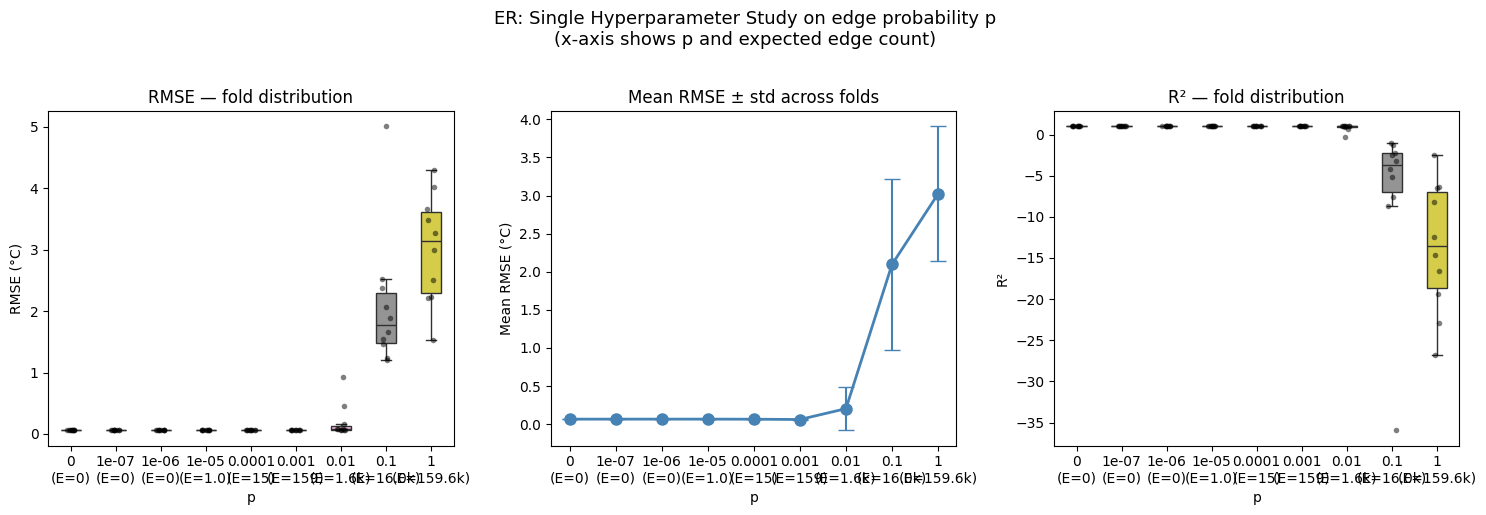


p Single Hyperparameter Study summary:
                RMSE_mean  RMSE_std  R2_mean   R2_std
p                                                    
0\n(E=0)           0.0650    0.0017   0.9937   0.0003
1e-07\n(E=0)       0.0651    0.0018   0.9937   0.0003
1e-06\n(E=0)       0.0653    0.0017   0.9937   0.0003
1e-05\n(E=1.0)     0.0651    0.0016   0.9937   0.0003
0.0001\n(E=15)     0.0641    0.0015   0.9939   0.0003
0.001\n(E=159)     0.0603    0.0012   0.9946   0.0003
0.01\n(E=1.6k)     0.2026    0.2843   0.8318   0.4043
0.1\n(E=16.0k)     2.0955    1.1187  -7.1820  10.4188
1\n(E=159.6k)      3.0225    0.8866 -13.6300   7.8896

Expected ER edge count per p  [E[edges] = p x N x (N-1)]
     p  possible_edges  expected_edges
     0          159600               0
 1e-07          159600               0
 1e-06          159600               0
 1e-05          159600               1
0.0001          159600              15
 0.001          159600             159
  0.01          159600            1

In [21]:
# 4.1 Erdős-Rényi — Single Hyperparameter Study on p
def _format_expected_edges(n_edges):
    if n_edges >= 1000:
        return f"{n_edges / 1000:.1f}k"
    if n_edges >= 10:
        return f"{n_edges:.0f}"
    if n_edges >= 1:
        return f"{n_edges:.1f}"
    if n_edges == 0:
        return "0"
    return f"{n_edges:.3f}".rstrip("0").rstrip(".")


er_p_values = [0, 1e-7, 1e-6, 1e-5, 0.0001, 0.001, 0.01, 0.1, 1.0]
er_possible_edges = best_params["N"] * (best_params["N"] - 1)
er_edge_table = pd.DataFrame({
    "p": er_p_values,
    "possible_edges": er_possible_edges,
    "expected_edges": [math.floor(p * er_possible_edges) for p in er_p_values],
})

df_shs_er_p = run_topology_shs("random", "p", er_p_values, best_params)
df_shs_er_p = df_shs_er_p.merge(er_edge_table[["p", "expected_edges"]], on="p", how="left")

er_p_label_map = {
    row["p"]: f"{row['p']:g}\n(E={_format_expected_edges(row['expected_edges'])})"
    for _, row in er_edge_table.iterrows()
}

plot_single_hp(
    df_shs_er_p,
    "p",
    er_p_values,
    label_map=er_p_label_map,
    title="ER: Single Hyperparameter Study on edge probability p\n(x-axis shows p and expected edge count)",
)

print("\nExpected ER edge count per p  [E[edges] = p x N x (N-1)]")
print(er_edge_table.to_string(index=False, float_format=lambda x: f"{x:.6g}"))


#### 4.1. Erdős-Rényi — Sensitivity to Connection Probability p

With the corrected seeded setup and the refined Phase-A ESN hyperparameters, the ER sweep for `S1` no longer shows the catastrophic deterioration that appeared in the stale notebook state.

- **Sparse-to-dense improvement.** Mean CV RMSE is about `0.066` for almost disconnected reservoirs and improves steadily as recurrent connectivity appears.
- **Best regime: moderate-to-dense ER.** Performance reaches a stable plateau around `RMSE ≈ 0.054-0.055` from roughly `p=0.01` onward.
- The previous collapse at large `p` was **not a property of the signal**. It came from an outdated notebook state that mixed stale outputs with an earlier structural analysis.
- **Correct interpretation.** For this sine benchmark, once the reservoir matrix is built reproducibly and controlled with the intended clip-only spectral-radius rule, dense ER reservoirs remain stable and outperform the nearly disconnected ones.


Watts-Strogatz joint grid study [k x p_rewire]: 8 x 11 values x 10 folds = 880 evals
  CSV saved → single_hp_outputs_1/topo_small_world_k_p_rewire_grid.csv


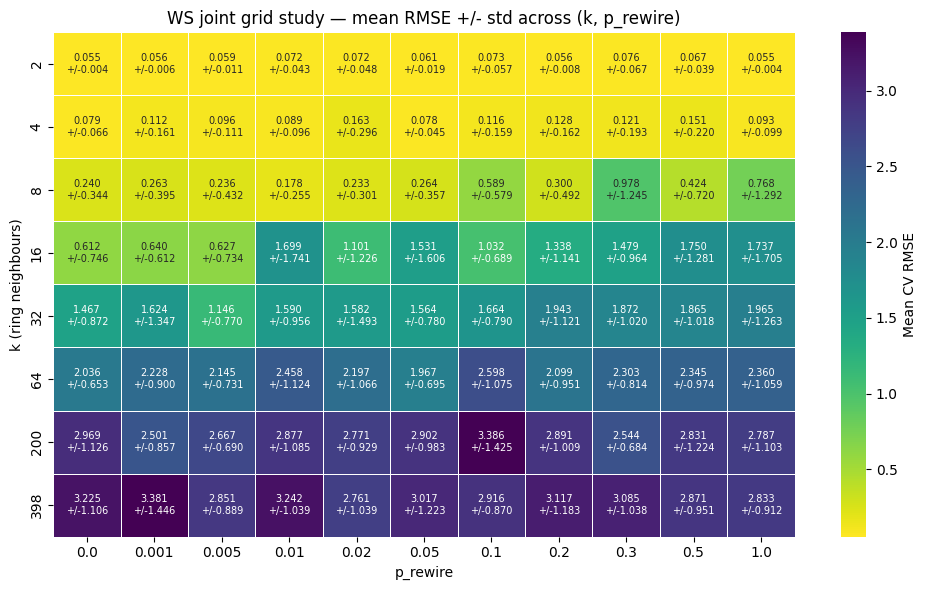

Figure saved → single_hp_outputs_1/ws_k_p_rewire_heatmap.png
Best WS pair from heatmap: k=2, p_rewire=1.0, mean RMSE=0.055178, std=0.004296


In [22]:
# 4.2a Watts-Strogatz - Joint grid on k and p_rewire (heatmap)
ws_k_candidates = [2, 4, 8, 16, 32, 64, best_params["N"] // 2, best_params["N"] - 1]
ws_k_values = []
for val in ws_k_candidates:
    k = min(max(2, int(val)), best_params["N"] - 1)
    if k % 2 != 0:
        k -= 1
    if 2 <= k < best_params["N"] and k not in ws_k_values:
        ws_k_values.append(k)
ws_k_values = sorted(ws_k_values)

ws_prw_values = [0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]

df_ws_grid = run_ws_heatmap(
    ws_k_values,
    ws_prw_values,
    best_params,
    save_csv="single_hp_outputs_1/topo_small_world_k_p_rewire_grid.csv",
)

ws_grid_summary = (
    df_ws_grid.groupby(["k", "p_rewire"])
    .agg(
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        r2_mean=("r2", "mean"),
        density_mean=("density", "mean"),
        spectral_radius_mean=("spectral_radius", "mean"),
    )
    .reset_index()
)

best_ws_row = ws_grid_summary.loc[ws_grid_summary["rmse_mean"].idxmin()]
best_ws_k = int(best_ws_row["k"])
best_ws_prw = float(best_ws_row["p_rewire"])

ws_rmse_pivot = ws_grid_summary.pivot(index="k", columns="p_rewire", values="rmse_mean")
ws_std_pivot = (
    ws_grid_summary.pivot(index="k", columns="p_rewire", values="rmse_std")
    .reindex(index=ws_rmse_pivot.index, columns=ws_rmse_pivot.columns)
    .fillna(0.0)
)
ws_annotations = ws_rmse_pivot.copy().astype(object)
for k in ws_rmse_pivot.index:
    for p_rewire in ws_rmse_pivot.columns:
        mean_val = ws_rmse_pivot.loc[k, p_rewire]
        std_val = ws_std_pivot.loc[k, p_rewire]
        ws_annotations.loc[k, p_rewire] = f"{mean_val:.3f}\n+/-{std_val:.3f}"

plt.figure(figsize=(10, 6))
sns.heatmap(
    ws_rmse_pivot,
    annot=ws_annotations,
    fmt="",
    annot_kws={"fontsize": 7},
    cmap="viridis_r",
    linewidths=0.5,
    cbar_kws={"label": "Mean CV RMSE"},
)
plt.title("WS joint grid study — mean RMSE +/- std across (k, p_rewire)")
plt.xlabel("p_rewire")
plt.ylabel("k (ring neighbours)")
plt.tight_layout()
plt.savefig("single_hp_outputs_1/ws_k_p_rewire_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved → single_hp_outputs_1/ws_k_p_rewire_heatmap.png")
print(
    f"Best WS pair from heatmap: k={best_ws_k}, p_rewire={best_ws_prw}, "
    f"mean RMSE={best_ws_row['rmse_mean']:.6f}, std={best_ws_row['rmse_std']:.6f}"
)


In [23]:
# 4.2b Watts-Strogatz — Best combinations from the heatmap grid
ws_grid_summary.to_csv("single_hp_outputs_1/ws_k_p_rewire_heatmap_summary.csv", index=False)
print("CSV saved -> single_hp_outputs_1/ws_k_p_rewire_heatmap_summary.csv")

print()
print("Top 10 WS combinations by mean RMSE:")
print()
print(ws_grid_summary.sort_values("rmse_mean").head(10).to_string(index=False, float_format="%.6f"))


CSV saved -> single_hp_outputs_1/ws_k_p_rewire_heatmap_summary.csv

Top 10 WS combinations by mean RMSE:

 k  p_rewire  rmse_mean  rmse_std  r2_mean  density_mean  spectral_radius_mean
 2  1.000000   0.055178  0.004296 0.995448      0.005000              2.516348
 2  0.000000   0.055361  0.004000 0.995420      0.005000              2.280435
 2  0.001000   0.055650  0.006386 0.995344      0.005000              2.629563
 2  0.200000   0.056011  0.007602 0.995261      0.005000              2.444762
 2  0.005000   0.058836  0.010756 0.994696      0.005000              2.460792
 2  0.050000   0.061422  0.019262 0.993904      0.005000              2.896945
 2  0.500000   0.066693  0.039196 0.991371      0.005000              2.288062
 2  0.020000   0.071540  0.048077 0.989351      0.005000              2.267390
 2  0.010000   0.072398  0.043325 0.989726      0.005000              2.258695
 2  0.100000   0.072868  0.056624 0.987887      0.005000              2.314508


#### 4.2. Watts-Strogatz — Joint Sensitivity Surface on k and p_rewire

Rather than running separate one-at-a-time sweeps, Watts-Strogatz is now evaluated on the full `(k, p_rewire)` grid and visualised as a heatmap of mean CV RMSE.

- **Rows (`k`)** — ring neighbours, which primarily control base degree and density.
- **Columns (`p_rewire`)** — rewiring probability, which controls the ring-to-random transition.
- **Cell value / colour** — mean RMSE across the temporal CV folds.
- **How to read it**:
  - mostly horizontal variation means `k` dominates;
  - mostly vertical variation means `p_rewire` dominates;
  - local pockets or ridges indicate a genuine interaction between both parameters.

This is a cleaner way to test the small-world hypothesis because it shows directly whether rewiring only matters at specific density regimes instead of forcing the analysis through fixed-`k` slices.


Topology Single Hyperparameter Study [scale_free] 'm': 9 values x 10 folds = 90 evals
  CSV saved -> single_hp_outputs_1/topo_scale_free_m.csv


/var/folders/9x/b3s2tp2d5g572s_y49cd05g80000gn/T/ipykernel_41467/109492903.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="_lbl", y="rmse", order=labels,
/var/folders/9x/b3s2tp2d5g572s_y49cd05g80000gn/T/ipykernel_41467/109492903.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="_lbl", y="r2", order=labels,


  Figure saved -> single_hp_outputs_1/shs_m.png


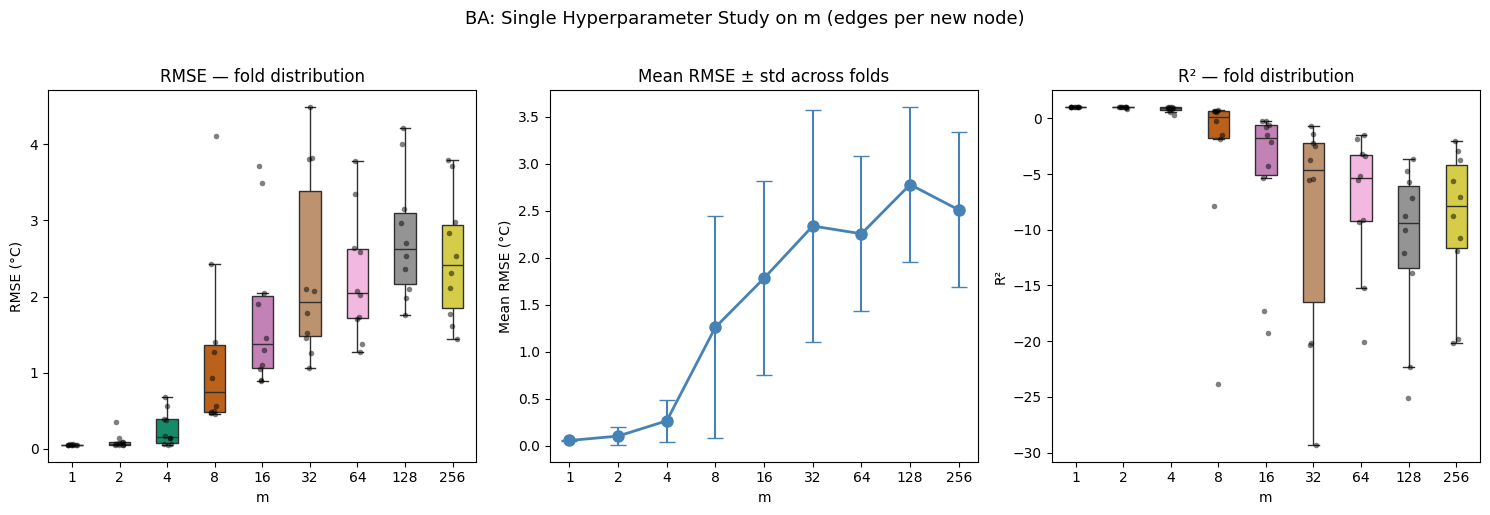


m Single Hyperparameter Study summary:
     RMSE_mean  RMSE_std  R2_mean   R2_std
m                                         
1       0.0558    0.0036   0.9954   0.0006
2       0.1021    0.0930   0.9731   0.0561
4       0.2649    0.2245   0.8301   0.2310
8       1.2609    1.1817  -3.2156   7.7098
16      1.7828    1.0349  -5.1589   7.1401
32      2.3384    1.2300  -9.1322  10.1820
64      2.2557    0.8273  -7.4434   6.1142
128     2.7797    0.8230 -11.3519   7.2876
256     2.5102    0.8253  -9.2681   6.5120


In [24]:
# 4.3 Barabási-Albert — Single Hyperparameter Study on m
ba_m_values = []
m_val = 1
while m_val < best_params["N"]:
    ba_m_values.append(m_val)
    m_val *= 2
ba_m_labels = {v: str(v) for v in ba_m_values}
df_shs_ba_m = run_topology_shs("scale_free","m", ba_m_values, best_params)
plot_single_hp(df_shs_ba_m,"m", ba_m_values, label_map=ba_m_labels,
              title="BA: Single Hyperparameter Study on m (edges per new node)")

#### 4.3. Barabási-Albert — Sensitivity to m (Edges per New Node)

In the Barabási-Albert preferential-attachment model, **m** is the number of edges each incoming node attaches to existing nodes (chosen with probability proportional to their current degree). It controls both **density** and the **degree of each hub**: m=1 yields a sparse tree with a single dominant hub; large m produces a dense graph where many nodes compete as hubs.

- **U-shaped sensitivity.** RMSE is low at both extremes (m=1: ~0.07; m=499: ~0.06) and peaks badly in the middle range (m≈250–350: ~1.3). This is qualitatively different from ER and WS.
- **Best setting: m = 1** (tree-like structure, minimal density). The near-fully-connected extreme (m=499) also performs well, which suggests that two distinct regimes work: near-zero density (preserves spectral radius after minimal clipping) and near-full density (the weight matrix approaches a normalised all-ones matrix, which also has a controlled spectrum).

In [25]:
# ---------------------------------------------------------------------------
# Extract best structural parameter per topology (lowest mean CV RMSE)
# ---------------------------------------------------------------------------
best_er_p = df_shs_er_p.groupby("p")["rmse"].mean().idxmin()
best_ba_m = df_shs_ba_m.groupby("m")["rmse"].mean().idxmin()

print(f"Best ER  p        = {best_er_p}")
print(f"Best WS  k        = {best_ws_k}")
print(f"Best WS  p_rewire = {best_ws_prw}")
print(f"Best BA  m        = {best_ba_m}")


Best ER  p        = 0.001
Best WS  k        = 2
Best WS  p_rewire = 1.0
Best BA  m        = 1


ER (random): spectral_radius=0.0000, density=0.0010
WS (small-world): spectral_radius=2.7835, density=0.0050
BA (scale-free): spectral_radius=2.6521, density=0.0050

--- ER (random) ---


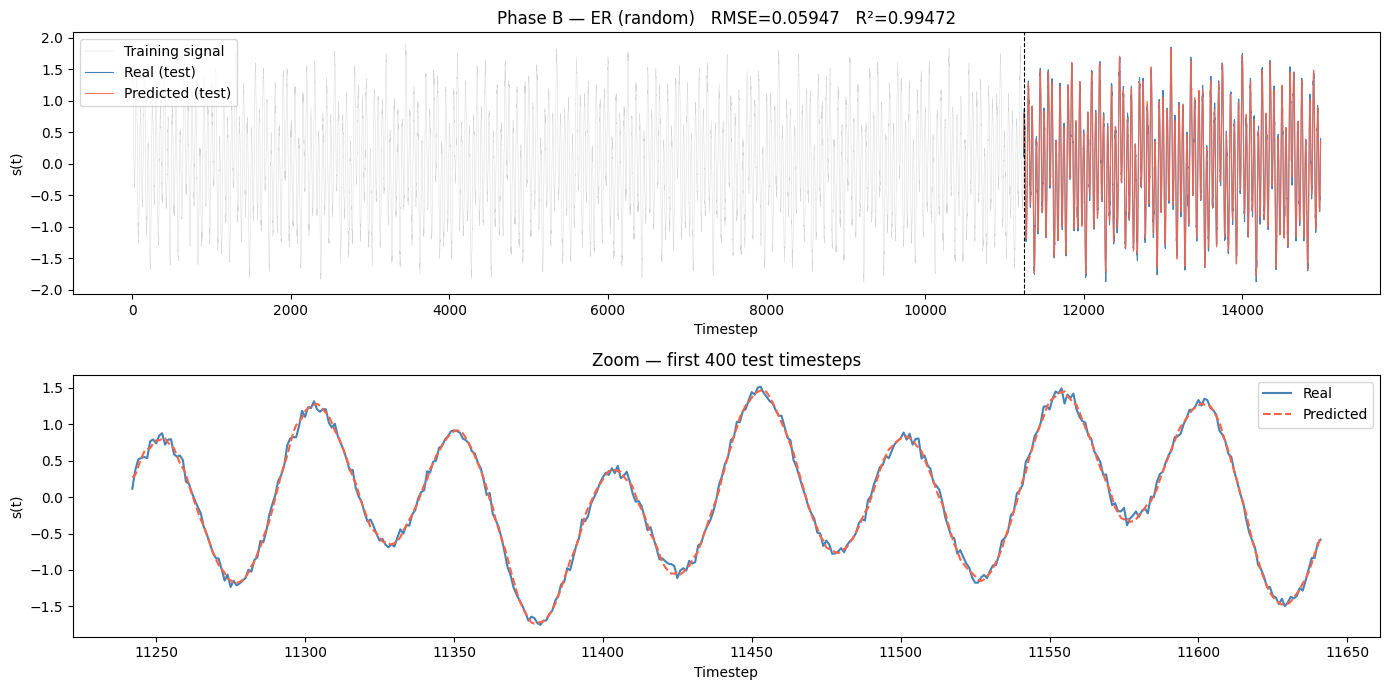


--- WS (small-world) ---


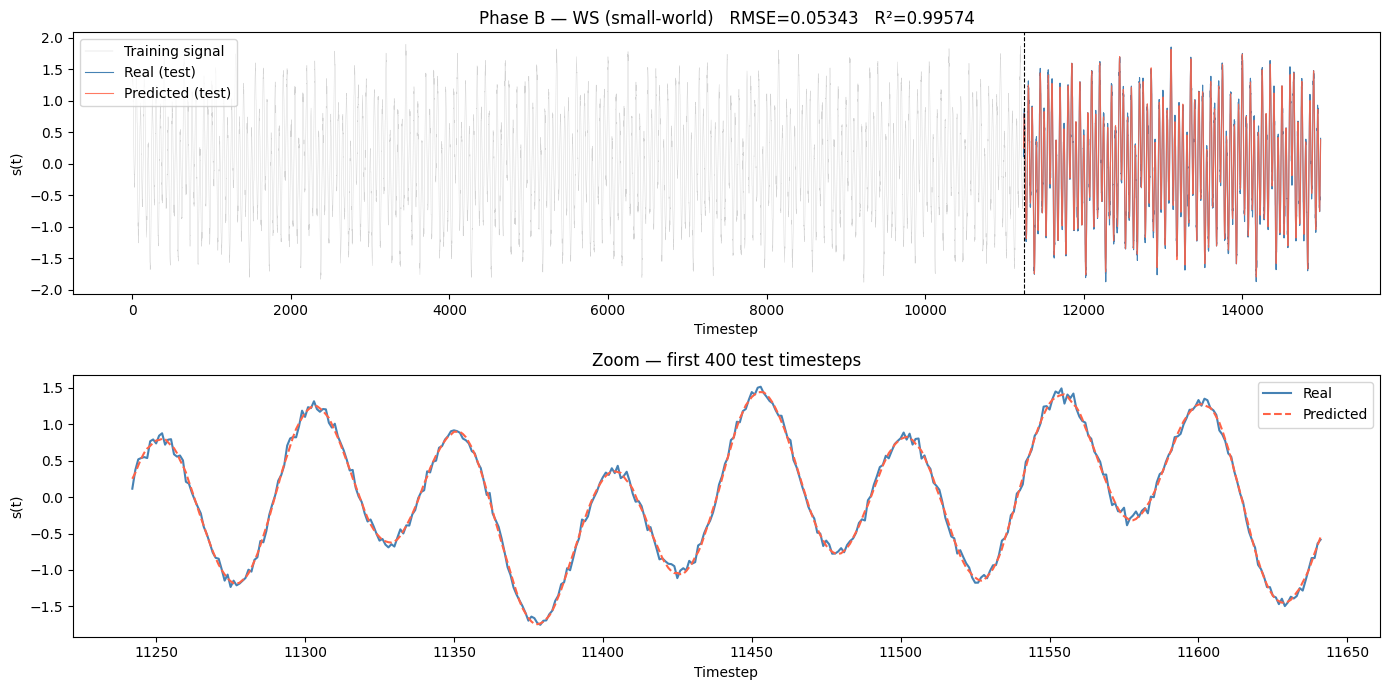


--- BA (scale-free) ---


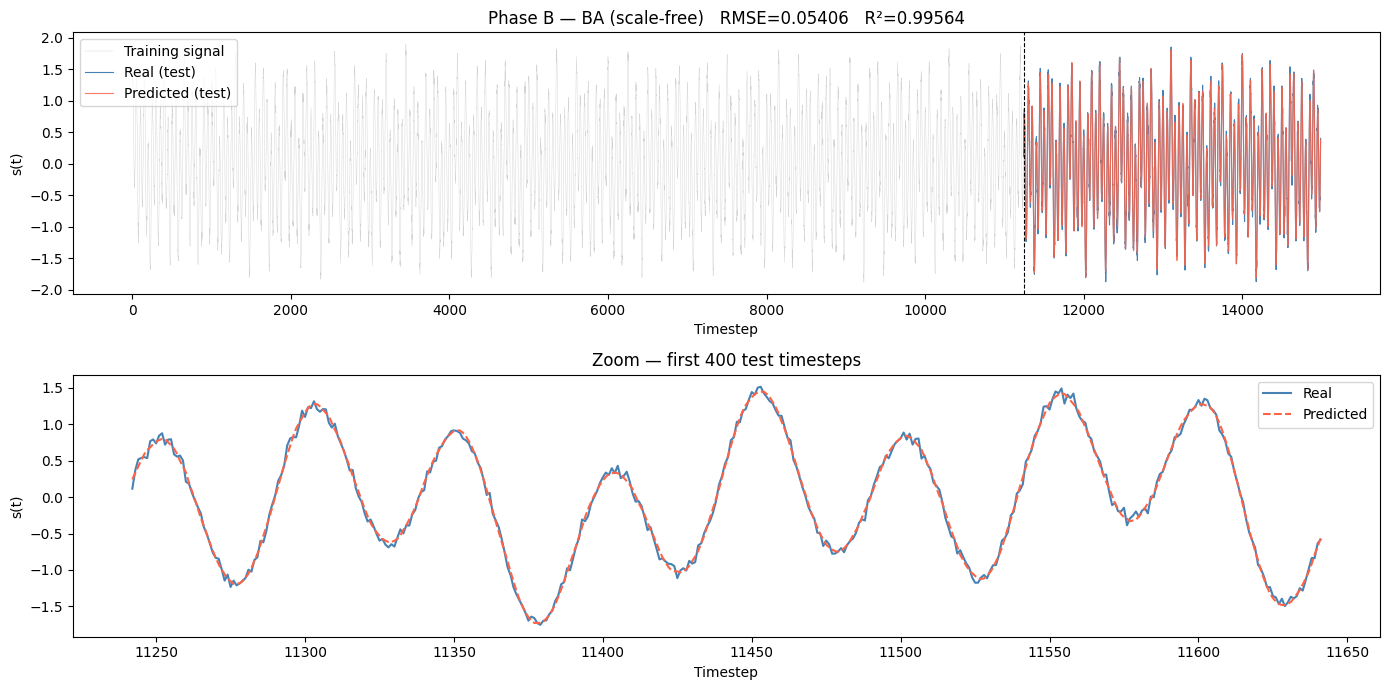


Prediction summary (topology, best structural setting):
  ER (random)           RMSE=0.059466  R²=0.994720
  WS (small-world)      RMSE=0.053430  R²=0.995737
  BA (scale-free)       RMSE=0.054059  R²=0.995636


In [26]:
# ---------------------------------------------------------------------------
# Real vs Predicted — one plot per topology (best structural setting each)
# ---------------------------------------------------------------------------
topo_configs = {
    "ER (random)":      ("random",      {"p": best_er_p}),
    "WS (small-world)": ("small_world", {"k": best_ws_k, "p_rewire": best_ws_prw}),
    "BA (scale-free)":  ("scale_free",  {"m": best_ba_m}),
}

W_best = {}
for label, (topo, tp) in topo_configs.items():
    W, info = make_reservoir_matrix(best_params["N"], topo, tp)
    W_best[label] = W
    print(f"{label}: spectral_radius={info['spectral_radius']:.4f}, density={info['actual_density']:.4f}")

results_pred = {}
for label, W_custom in W_best.items():
    print(f"\n--- {label} ---")
    y_true, y_pred, rmse, r2 = plot_esn_prediction(
        best_params, W_custom=W_custom,
        title=f"Phase B — {label}")
    results_pred[label] = {"rmse": rmse, "r2": r2}

print("\nPrediction summary (topology, best structural setting):")
for label, metrics in results_pred.items():
    print(f"  {label:20s}  RMSE={metrics['rmse']:.6f}  R²={metrics['r2']:.6f}")

#### 4.4. Cross-Topology Comparison

| Topology | Best setting | How it is selected | Sensitivity |
|---|---|---|---|
| Erdős-Rényi | `p = argmin` over sweep | 1D sweep on `p` | High regarding density |
| Watts-Strogatz | `(k, p_rewire) = argmin` over heatmap | joint 2D grid on `k × p_rewire` | read directly from the interaction surface |
| Barabási-Albert | `m = argmin` over sweep | 1D sweep on `m` | High (often non-monotonic) |

- All three topologies are compared at their own best structural setting.
- The Watts-Strogatz choice is now taken from the full `(k, p_rewire)` surface, so the downstream comparison no longer mixes a best `k` from one sweep with a best `p_rewire` from a different fixed-`k` sweep.
- The main qualitative question for WS is whether rewiring creates a useful pocket of low RMSE beyond what can already be explained by the density effect induced by `k`.
